In [69]:
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


# 1. Import Required Libraries

The first step is to import the Python libraries required for data analysis, visualization, preprocessing, clustering, and machine-learning model development.

The main libraries used in this project are:

* **Pandas** for loading, cleaning, and analyzing tabular data.
* **NumPy** for numerical calculations.
* **Matplotlib** and **Seaborn** for creating charts and visualizations.
* **Scikit-learn** for preprocessing, clustering, model training, and evaluation.
* **Imbalanced-learn** for handling class imbalance using SMOTE.

The installed library versions are also displayed to confirm that the project environment is configured correctly.


In [70]:
# Import the main libraries to confirm that the environment is ready

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn

print("The project environment is ready.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Imbalanced-learn version:", imblearn.__version__)

The project environment is ready.
Pandas version: 3.0.3
NumPy version: 2.4.6
Scikit-learn version: 1.9.0
Imbalanced-learn version: 0.14.2


# Project: Employee Turnover Analytics

## # 2. Load and Inspect the Dataset

The employee-turnover dataset is loaded and inspected before performing data-quality checks, exploratory analysis, clustering, and machine-learning modeling.

The purpose of this section is to:

* Confirm that the dataset file is available.
* Load the CSV file into a Pandas DataFrame.
* Review the dataset dimensions.
* Preview employee records.
* Examine the column names.
* Understand the structure and data types of the variables.

This initial inspection helps verify that the dataset was loaded correctly and identifies any changes required before analysis.
## Load and Inspect the Dataset

In this section, the employee turnover dataset is loaded into a Pandas DataFrame. The dataset structure, dimensions, column names, data types, and sample records are reviewed before performing data-quality checks and exploratory data analysis.

## 2.1 Verify the Project Folder and Files

Before loading the dataset, the notebook checks the current working directory and lists the files available in the project folder.

This confirms that Python is working in the correct folder and that the `HR_comma_sep.csv` dataset is available in the same location as the notebook.


In [71]:
# Import the operating system library
import os

# Display the folder currently being used by the notebook
print("Current project folder:")
print(os.getcwd())

# Display the files available inside the project folder
print("\nFiles in the project folder:")
print(os.listdir())

Current project folder:
c:\Users\amro_\Documents\Simplilearn\Machine Learning\Project_Employee_Turnover_Analytics

Files in the project folder:
['.venv', 'Employee_Turnover_Analytics.ipynb', 'employee_turnover_risk_results.csv', 'HR_comma_sep.csv']


## 2.2 Load the Employee Turnover Dataset

The employee-turnover CSV file is loaded into a Pandas DataFrame named `df`.

A DataFrame is a table-like Python structure containing rows and columns, similar to an Excel worksheet. Each row represents an employee record, while each column represents an employee characteristic.

The original dataset names the department column `sales`. Because this column contains multiple department categories and the project description identifies it as the department variable, it is renamed to `Department` immediately after loading.


In [72]:
# Store the dataset filename in a variable
file_name = "HR_comma_sep.csv"

# Read the CSV file and store it in a Pandas DataFrame named df
df = pd.read_csv(file_name)

# Print a confirmation message
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 2.3 Review the Dataset Dimensions

The number of rows and columns in the dataset is reviewed using the DataFrame `shape` attribute.

The number of rows represents the total number of employee records, while the number of columns represents the employee variables available for analysis.


In [73]:
# Display the total number of rows and columns
print("Dataset dimensions:", df.shape)

# Display the number of employee records
print("Number of rows:", df.shape[0])

# Display the number of columns
print("Number of columns:", df.shape[1])

Dataset dimensions: (14999, 10)
Number of rows: 14999
Number of columns: 10


### Interpretation

The dataset contains **14,999 employee records** and **10 variables**.

Each row represents one employee observation, while the columns describe employee satisfaction, performance, workload, tenure, work accidents, turnover status, promotion history, department, and salary level.


## 2.4 Preview the Employee Records

The first five rows of the dataset are displayed using the `head()` function.

Previewing the data helps confirm that the CSV file was loaded correctly and provides an initial understanding of how employee information is organized across the columns.


In [74]:
# Display the first five rows of the dataset
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Interpretation

The preview confirms that the dataset was loaded successfully.

Each row represents an employee and contains information about satisfaction, evaluation score, number of projects, average monthly working hours, company tenure, work accidents, turnover status, promotion history, department, and salary level.

The `left` variable is the target column:

* `0` indicates that the employee stayed with the company.
* `1` indicates that the employee left the company.


## 2.5 Review the Column Names

The dataset column names are reviewed to confirm that all required variables are present and correctly labeled.

This step also confirms that the original `sales` column was successfully renamed to `Department`.


In [75]:
# Display all column names
print("Dataset columns:")

for column in df.columns:
    print(column)

Dataset columns:
satisfaction_level
last_evaluation
number_project
average_montly_hours
time_spend_company
Work_accident
left
promotion_last_5years
sales
salary


### Interpretation

The dataset contains the following 10 variables:

* `satisfaction_level`
* `last_evaluation`
* `number_project`
* `average_montly_hours`
* `time_spend_company`
* `Work_accident`
* `left`
* `promotion_last_5years`
* `Department`
* `salary`

The department variable is now correctly named `Department`.

The spelling `average_montly_hours` is retained because it is the original column name in the dataset. The exact spelling must be used when referencing this variable in Python code.


In [76]:
# Store the dataset filename in a variable
file_name = "HR_comma_sep.csv"

# Read the CSV file and store it in a Pandas DataFrame named df
df = pd.read_csv(file_name)

# Rename the incorrectly named 'sales' column to 'Department'
df.rename(columns={"sales": "Department"}, inplace=True)

# Print a confirmation message
print("Dataset loaded successfully.")
print("The 'sales' column was renamed to 'Department'.")

Dataset loaded successfully.
The 'sales' column was renamed to 'Department'.


In [77]:
# Display the updated column names
print("Updated dataset columns:")

for column in df.columns:
    print(column)

Updated dataset columns:
satisfaction_level
last_evaluation
number_project
average_montly_hours
time_spend_company
Work_accident
left
promotion_last_5years
Department
salary


## 2.6 Examine the Dataset Structure

The purpose of this step is to understand the overall structure of the employee turnover dataset.

The `info()` function is used to display the number of rows and columns, the column names, the number of non-null values, and the data type of each variable. This check helps confirm whether the dataset was loaded correctly and whether any columns require data-type conversion before analysis.


In [78]:
# Display detailed information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


## 2.7 Descriptive Statistics

The purpose of this step is to summarize the numerical variables in the employee dataset. Descriptive statistics such as the mean, minimum, maximum, median, and standard deviation help identify the general distribution and range of employee characteristics.

The `describe()` function is used to generate summary statistics for all numerical columns.

In [79]:
# Display descriptive statistics for all numerical columns
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Interpretation

The average employee satisfaction level is approximately 61.3%, while the average evaluation score is approximately 71.6%.

Employees work on approximately four projects and spend an average of 201 hours per month at work. Monthly working hours range from 96 to 310 hours, showing considerable variation in workload.

Employees have worked for the company for approximately 3.5 years on average. Approximately 23.8% of employees left the company, while only about 2.1% received a promotion during the last five years.

These results suggest that satisfaction, workload, project count, company tenure, and promotion opportunities may be important factors to examine during exploratory data analysis.

## 2.8 Examine the Categorical Variables

The dataset contains two categorical variables: `Department` and `salary`.

The purpose of this step is to identify the unique categories in each variable and determine how many employees belong to each category. This helps detect unexpected values, spelling inconsistencies, and category imbalance before preprocessing the data.

In [80]:
# Display the unique values in the Department column
print("Unique departments:")
print(df["Department"].unique())

# Display the number of employees in each department
print("\nNumber of employees in each department:")
print(df["Department"].value_counts())

# Display the unique values in the salary column
print("\nUnique salary levels:")
print(df["salary"].unique())

# Display the number of employees in each salary level
print("\nNumber of employees in each salary level:")
print(df["salary"].value_counts())

Unique departments:
<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

Number of employees in each department:
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

Unique salary levels:
<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

Number of employees in each salary level:
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


### Interpretation

The dataset contains 10 unique departments. The Sales department has the largest number of employees, with 4,140 employees, followed by Technical with 2,720 employees and Support with 2,229 employees. Management is the smallest department, with 630 employees.

The salary variable contains three categories: low, medium, and high. Most employees are in the low-salary category, with 7,316 employees, followed by 6,446 employees in the medium-salary category. Only 1,237 employees are in the high-salary category.

This distribution shows that the employee population is not evenly distributed across departments or salary levels. The relatively small number of high-salary employees may be important when examining whether salary level is associated with employee turnover.

No unexpected categories or obvious spelling inconsistencies were identified in the Department or salary columns.


# 3. Data-Quality Checks

## 3.1 Check for Missing Values

Missing values can affect the accuracy of data analysis and machine-learning models. Therefore, the first data-quality check is to determine whether any column contains null or missing values.

The `isnull()` function identifies missing values, while `sum()` calculates the total number of missing values in each column.

In [81]:
# Count the number of missing values in each column
missing_values = df.isnull().sum()

# Display the missing-value count
print("Missing values in each column:")
print(missing_values)

# Display the total number of missing values in the dataset
print("\nTotal missing values in the dataset:", missing_values.sum())

Missing values in each column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Total missing values in the dataset: 0


### Interpretation

The missing-value analysis shows that all 10 columns contain complete data. The total number of missing values in the dataset is zero.

Therefore, no missing-value treatment, such as deleting records or replacing missing values with the mean, median, mode, or another value, is required before continuing the analysis.

## 3.2 Check for Duplicate Records

Duplicate records may cause certain employee patterns to be counted more than once, which can affect descriptive statistics, visualizations, and machine-learning model performance.

The `duplicated()` function is used to identify rows that contain exactly the same values as an earlier row. The duplicate records will be counted and reviewed before any records are removed.

In [82]:
# Count the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

# Display the number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 3008


### Interpretation

The duplicate-record check identified 3,008 rows that exactly match earlier rows in the dataset.

Because the dataset does not include a unique employee identifier, it is not possible to independently confirm whether employees with identical information are different individuals. For the purpose of this analysis, exact duplicate rows will be treated as duplicate observations and removed.

Removing these records helps prevent repeated observations from influencing the exploratory analysis and machine-learning models more than once.


## 3.3 Remove Duplicate Records

The 3,008 exact duplicate rows identified in the previous step will be removed.

Before removing them, a copy of the original dataset will be retained. The DataFrame index will also be reset so that the remaining rows have a continuous index beginning at zero.


In [83]:
# Create a backup copy of the original dataset
original_df = df.copy()

# Store the number of rows before removing duplicates
rows_before = df.shape[0]

# Remove exact duplicate rows
df = df.drop_duplicates()

# Reset the row index after removing duplicates
df = df.reset_index(drop=True)

# Store the number of rows after removing duplicates
rows_after = df.shape[0]

# Calculate the number of rows removed
rows_removed = rows_before - rows_after

# Display the cleaning results
print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed:", rows_removed)
print("Rows after removing duplicates:", rows_after)

# Confirm that no duplicate rows remain
print("Duplicate rows remaining:", df.duplicated().sum())

Rows before removing duplicates: 14999
Duplicate rows removed: 3008
Rows after removing duplicates: 11991
Duplicate rows remaining: 0


### Interpretation

A total of 3,008 exact duplicate rows were removed from the dataset. After cleaning, the dataset contains 11,991 unique employee records.

A final duplicate check returned zero, confirming that no exact duplicate rows remain. The cleaned dataset will be used for the remaining analysis and machine-learning steps.


## 3.4 Validate Categorical and Binary Values

This step checks the unique values in the categorical and binary columns.

The binary variables should contain only `0` and `1`, while the categorical variables should contain only the expected department and salary categories. Reviewing these values helps identify incorrect labels, spelling inconsistencies, or unexpected data entries.


In [84]:
# Display unique values in the binary columns
print("Unique values in Work_accident:")
print(df["Work_accident"].unique())

print("\nUnique values in left:")
print(df["left"].unique())

print("\nUnique values in promotion_last_5years:")
print(df["promotion_last_5years"].unique())

# Display unique values in the categorical columns
print("\nUnique values in Department:")
print(df["Department"].unique())

print("\nUnique values in salary:")
print(df["salary"].unique())

Unique values in Work_accident:
[0 1]

Unique values in left:
[1 0]

Unique values in promotion_last_5years:
[0 1]

Unique values in Department:
<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

Unique values in salary:
<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str


### Interpretation

The categorical and binary value checks did not identify any invalid or unexpected values.

The `Work_accident`, `left`, and `promotion_last_5years` columns contain only the expected binary values of 0 and 1. The Department column contains 10 valid department categories, while the salary column contains the expected low, medium, and high categories.

Therefore, no corrections are required for the categorical or binary variables.


## 3.5 Validate Numerical Ranges

This step examines the minimum and maximum values of all numerical variables.

Range validation helps identify impossible or unexpected values that may indicate data-entry errors. Satisfaction and evaluation scores should fall between 0 and 1, while project counts, monthly working hours, and company tenure should contain reasonable positive values.


In [85]:
# Select all numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Display the minimum and maximum value for each numerical column
print("Minimum and maximum values for numerical columns:\n")

for column in numerical_columns:
    minimum_value = df[column].min()
    maximum_value = df[column].max()

    print(
        f"{column}: "
        f"Minimum = {minimum_value}, "
        f"Maximum = {maximum_value}"
    )

Minimum and maximum values for numerical columns:

satisfaction_level: Minimum = 0.09, Maximum = 1.0
last_evaluation: Minimum = 0.36, Maximum = 1.0
number_project: Minimum = 2, Maximum = 7
average_montly_hours: Minimum = 96, Maximum = 310
time_spend_company: Minimum = 2, Maximum = 10
Work_accident: Minimum = 0, Maximum = 1
left: Minimum = 0, Maximum = 1
promotion_last_5years: Minimum = 0, Maximum = 1


### Interpretation

The numerical range validation did not identify any impossible or unexpected values.

Employee satisfaction ranges from 0.09 to 1.00, while evaluation scores range from 0.36 to 1.00. Employees work on between 2 and 7 projects, spend between 96 and 310 hours per month at work, and have between 2 and 10 years of company tenure.

The `Work_accident`, `left`, and `promotion_last_5years` variables contain only the expected binary values of 0 and 1.

Therefore, no numerical values need to be corrected or removed.


## Data-Quality Summary

The dataset initially contained 14,999 employee records and 10 variables.

No missing values were identified. However, 3,008 exact duplicate rows were found and removed, leaving 11,991 unique employee records for analysis.

The categorical, binary, and numerical variables were also validated. No invalid categories, unexpected binary values, or unreasonable numerical values were identified.

The cleaned dataset is now ready for exploratory data analysis.


# 4. Exploratory Data Analysis

Exploratory Data Analysis, or EDA, is used to examine patterns, relationships, and trends within the employee dataset.

The purpose of this section is to understand which employee characteristics may be associated with employee turnover. The analysis will examine numerical correlations, variable distributions, and differences between employees who stayed and employees who left.

## 4.1 Correlation Matrix Heatmap

A correlation matrix measures the strength and direction of the relationship between numerical variables.

Correlation values range from -1 to 1:

* A value close to 1 indicates a strong positive relationship.
* A value close to -1 indicates a strong negative relationship.
* A value close to 0 indicates little or no linear relationship.

The heatmap will help identify which numerical employee characteristics have the strongest relationships with the target variable, `left`.


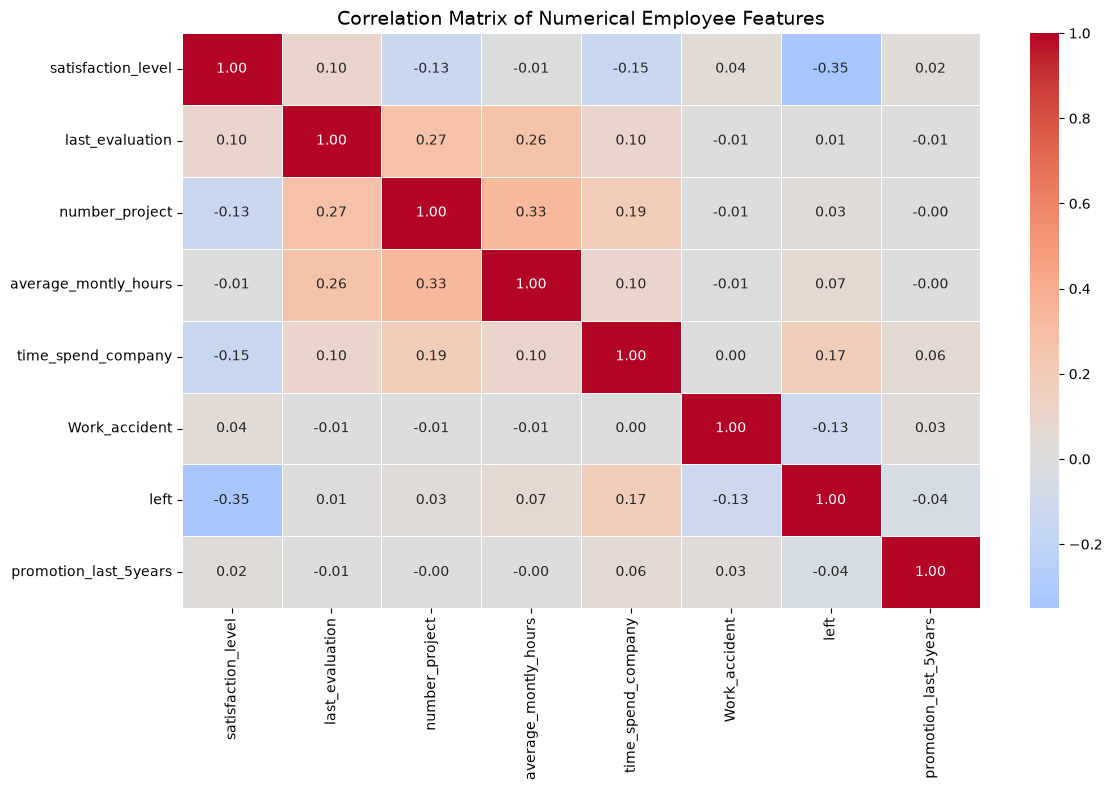

In [86]:
# Select only the numerical columns
numerical_data = df.select_dtypes(include=["number"])

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Set the size of the chart
plt.figure(figsize=(12, 8))

# Create the correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

# Add a chart title
plt.title(
    "Correlation Matrix of Numerical Employee Features",
    fontsize=14
)

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows that `satisfaction_level` has the strongest relationship with employee turnover. Its correlation with `left` is **-0.35**, indicating that employees with lower satisfaction levels are more likely to leave the company.

The variable `time_spend_company` has a positive correlation of **0.17** with turnover. This suggests that turnover may become more likely at certain levels of company tenure.

`Work_accident` has a correlation of **-0.13** with turnover. This indicates a weak tendency for employees who experienced a work accident to be less likely to leave, although this relationship is not strong.

`average_montly_hours` has a weak positive correlation of **0.07** with turnover. This suggests that employees working longer hours may be slightly more likely to leave.

The remaining variables have very weak linear correlations with turnover:

* `promotion_last_5years`: **-0.04**
* `number_project`: **0.03**
* `last_evaluation`: **0.01**

The heatmap also shows a positive relationship between `number_project` and `average_montly_hours`, with a correlation of **0.33**. Employees assigned to more projects generally tend to work more hours.

Overall, employee satisfaction appears to be the most important numerical factor associated with turnover in the correlation analysis. However, correlation measures only linear relationships and does not prove causation. Some variables may still influence turnover through nonlinear patterns or interactions with other features.


## 4.2 Distribution of Employee Characteristics

Distribution plots are used to understand how numerical employee characteristics are spread across the dataset.

This analysis examines the distributions of:

* Employee satisfaction level
* Last employee evaluation score
* Average monthly working hours

Each chart combines a histogram with a density curve. The histogram shows how many employees fall within different value ranges, while the density curve helps reveal the overall shape and concentration of the data.


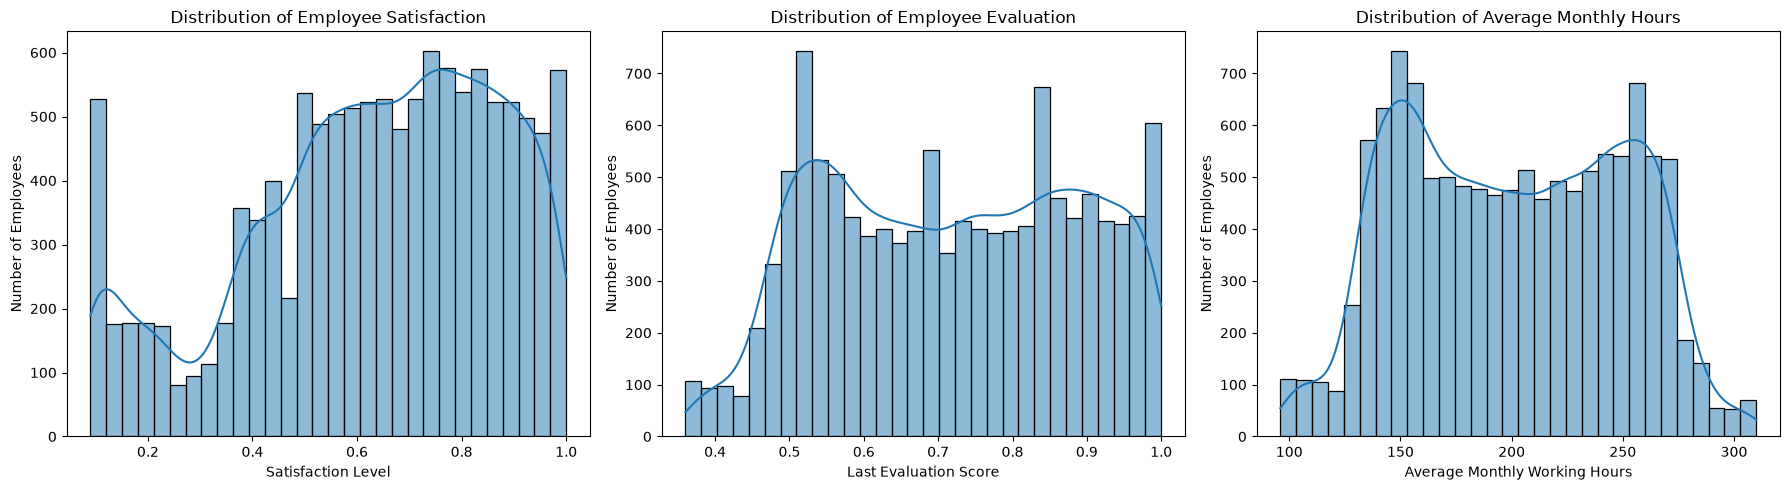

In [87]:
# Create one figure containing three charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot the distribution of employee satisfaction
sns.histplot(
    data=df,
    x="satisfaction_level",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Employee Satisfaction")
axes[0].set_xlabel("Satisfaction Level")
axes[0].set_ylabel("Number of Employees")

# Plot the distribution of employee evaluation scores
sns.histplot(
    data=df,
    x="last_evaluation",
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of Employee Evaluation")
axes[1].set_xlabel("Last Evaluation Score")
axes[1].set_ylabel("Number of Employees")

# Plot the distribution of average monthly working hours
sns.histplot(
    data=df,
    x="average_montly_hours",
    bins=30,
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Distribution of Average Monthly Hours")
axes[2].set_xlabel("Average Monthly Working Hours")
axes[2].set_ylabel("Number of Employees")

# Prevent titles and labels from overlapping
plt.tight_layout()

# Display the charts
plt.show()

### Distribution Plot Interpretation

The employee satisfaction distribution shows several distinct patterns rather than one normal distribution. A noticeable group of employees has very low satisfaction levels between approximately 0.10 and 0.30. A much larger group has moderate-to-high satisfaction levels between approximately 0.50 and 1.00. This separation suggests that some employees may belong to a dissatisfied group that should be examined more closely for turnover risk.

The employee evaluation distribution also contains multiple concentrations. One group is centered around evaluation scores of approximately 0.50 to 0.60, while another group has higher evaluation scores between approximately 0.80 and 1.00. This indicates that employees may fall into different performance groups.

The average monthly working-hours distribution shows two noticeable concentrations. One group works approximately 140 to 170 hours per month, while another group works approximately 240 to 270 hours per month. The second group may represent employees with relatively high workloads.

Overall, the distributions suggest that the employee population contains several distinct groups. In particular, employees with low satisfaction and employees working very high monthly hours may require further investigation. However, these charts describe the overall workforce and do not yet show whether these employees stayed or left.


## 4.3 Employee Project Count by Turnover Status

This analysis compares the number of projects assigned to employees who stayed with the company and employees who left.

A grouped count plot is used, where the horizontal axis represents the number of projects and the bar colors separate employees by turnover status:

* `left = 0` represents employees who stayed.
* `left = 1` represents employees who left.

The purpose is to identify whether employees with very low or very high project workloads appear more likely to leave the organization.


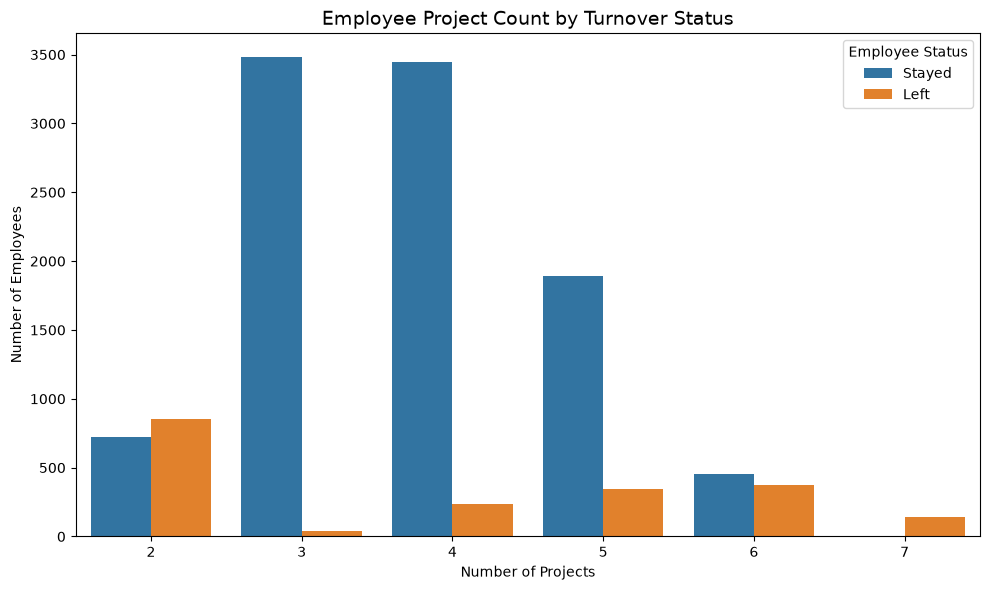

In [88]:
# Set the size of the chart
plt.figure(figsize=(10, 6))

# Create a grouped bar plot of project counts by turnover status
sns.countplot(
    data=df,
    x="number_project",
    hue="left"
)

# Add the chart title and axis labels
plt.title(
    "Employee Project Count by Turnover Status",
    fontsize=14
)

plt.xlabel("Number of Projects")
plt.ylabel("Number of Employees")

# Rename the legend values so they are easier to understand
plt.legend(
    title="Employee Status",
    labels=["Stayed", "Left"]
)

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

### Project Count Interpretation

The project-count analysis shows that employee turnover varies considerably according to the number of projects assigned.

Employees working on only **two projects** have a high level of turnover. In this group, the number of employees who left is greater than the number who stayed. This may indicate that employees with too little work feel underutilized, disengaged, or dissatisfied.

Employees working on **three or four projects** have the lowest apparent turnover. Most employees in these groups remained with the company, suggesting that a moderate project workload may be more sustainable.

Turnover begins to increase among employees assigned **five or six projects**. For employees working on six projects, the number who left is relatively close to the number who stayed, indicating a much higher turnover proportion.

All employees assigned **seven projects** appear to have left the company. This may indicate that extremely high project workloads contribute to stress, overwork, or burnout.

Overall, the chart suggests a U-shaped relationship between project workload and turnover. Employees with either very low or very high project assignments appear more likely to leave, while employees with moderate workloads of three or four projects are more likely to stay.

This analysis shows an association between project workload and turnover but does not establish that project count directly causes employees to leave.


# 5. Employee Clustering Using K-Means

Clustering is an unsupervised machine-learning technique used to group observations with similar characteristics.

In this section, K-means clustering will be used to divide employees who left the company into three groups based on:

* Satisfaction level
* Last evaluation score

The purpose is to identify different types of employees who left and better understand the patterns associated with turnover.

## 5.1 Select Employees Who Left

Before performing clustering, the dataset is filtered to include only employees whose `left` value equals 1.

Only the `satisfaction_level`, `last_evaluation`, and `left` columns are selected, as required by the project instructions.


In [89]:
# Select the required columns
clustering_data = df[
    ["satisfaction_level", "last_evaluation", "left"]
].copy()

# Keep only employees who left the company
employees_left = clustering_data[
    clustering_data["left"] == 1
].copy()

# Reset the index
employees_left = employees_left.reset_index(drop=True)

# Display the first five employee records
employees_left.head()

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


5.2: Check the number of employees selected

In [90]:
# Display the number of employees who left
print("Number of employees who left:", employees_left.shape[0])

# Display the number of selected columns
print("Number of columns selected:", employees_left.shape[1])

# Confirm the selected column names
print("\nColumns used:")
print(employees_left.columns.tolist())

Number of employees who left: 1991
Number of columns selected: 3

Columns used:
['satisfaction_level', 'last_evaluation', 'left']


### Interpretation

After removing duplicate records, 1,991 employees in the cleaned dataset are identified as having left the company.

The clustering dataset contains the three required columns: `satisfaction_level`, `last_evaluation`, and `left`. Because all selected employees have a `left` value of 1, the actual clustering will be based on satisfaction level and last evaluation score.

The `left` column is retained to document that the analysis includes only employees who left, but it will not be used as a clustering feature because it has the same value for every selected employee.


## 5.3 Apply K-Means Clustering

K-means clustering divides employees into groups based on similarity.

For this analysis, three clusters will be created using:

* `satisfaction_level`
* `last_evaluation`

The `left` column is not included as a clustering input because every employee in this subset has the same value of 1. A constant variable cannot help distinguish one cluster from another.

The model uses a fixed random state so that the clustering results remain reproducible each time the notebook is run.


In [91]:
# Import the K-Means clustering algorithm
from sklearn.cluster import KMeans

# Select the two features used to create the clusters
clustering_features = employees_left[
    ["satisfaction_level", "last_evaluation"]
]

# Create the K-Means model with three clusters
kmeans_model = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=10
)

# Train the model and assign a cluster number to each employee
employees_left["cluster"] = kmeans_model.fit_predict(
    clustering_features
)

# Display the first five records with their assigned clusters
employees_left.head()

,satisfaction_level,last_evaluation,left,cluster
0,0.38,0.53,1,2
1,0.80,0.86,1,1
2,0.11,0.88,1,0
3,0.72,0.87,1,1
4,0.37,0.52,1,2


## 5.4 Review the Cluster Results

The number of employees in each cluster and the cluster-center values are reviewed to understand the characteristics of the three employee groups.

A cluster center represents the average satisfaction and evaluation values around which the employees in that cluster are grouped.

In [92]:
# Count the number of employees assigned to each cluster
cluster_counts = employees_left["cluster"].value_counts().sort_index()

print("Number of employees in each cluster:")
print(cluster_counts)

# Create a table containing the cluster centers
cluster_centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=["satisfaction_level", "last_evaluation"]
)

# Add the cluster number as a column
cluster_centers.insert(
    0,
    "cluster",
    range(len(cluster_centers))
)

print("\nCluster centers:")
display(cluster_centers.round(3))

Number of employees in each cluster:
cluster
0    534
1    555
2    902
Name: count, dtype: int64

Cluster centers:


,cluster,satisfaction_level,last_evaluation
0,0,0.111,0.869
1,1,0.806,0.913
2,2,0.410,0.517


### Cluster Center Interpretation

K-means clustering divided the 1,991 employees who left the company into three distinct groups.

**Cluster 0 contains 534 employees.** This group has a very low average satisfaction level of approximately 0.111 and a high average evaluation score of approximately 0.869. These employees can be described as **high-performing but highly dissatisfied employees**. Their strong evaluation scores suggest that performance was not the main issue, while their extremely low satisfaction may have contributed to their decision to leave.

**Cluster 1 contains 555 employees.** This group has a high average satisfaction level of approximately 0.806 and a high average evaluation score of approximately 0.913. These employees can be described as **high-performing and highly satisfied employees who still left the company**. Their departure may have been influenced by factors not included in the clustering analysis, such as compensation, career opportunities, workload, management, or personal circumstances.

**Cluster 2 contains 902 employees.** This is the largest cluster. It has a moderately low average satisfaction level of approximately 0.410 and a lower average evaluation score of approximately 0.517. These employees can be described as **moderately dissatisfied employees with lower evaluation scores**. This group may require performance support, clearer expectations, coaching, or better job-role alignment.

Overall, the clustering results show that employee turnover is not limited to one type of employee. The company lost highly dissatisfied high performers, satisfied high performers, and employees with lower satisfaction and evaluation scores. Therefore, different retention strategies may be needed for each employee group.


## 5.5 Visualize the Employee Clusters

A scatter plot is used to visualize the three groups of employees who left the company.

Each point represents one employee. The employee's satisfaction level is displayed on the horizontal axis, while the last evaluation score is displayed on the vertical axis. The colors represent the cluster assigned by the K-means model.

The cluster centers are marked with large `X` symbols to show the average position of each employee group.


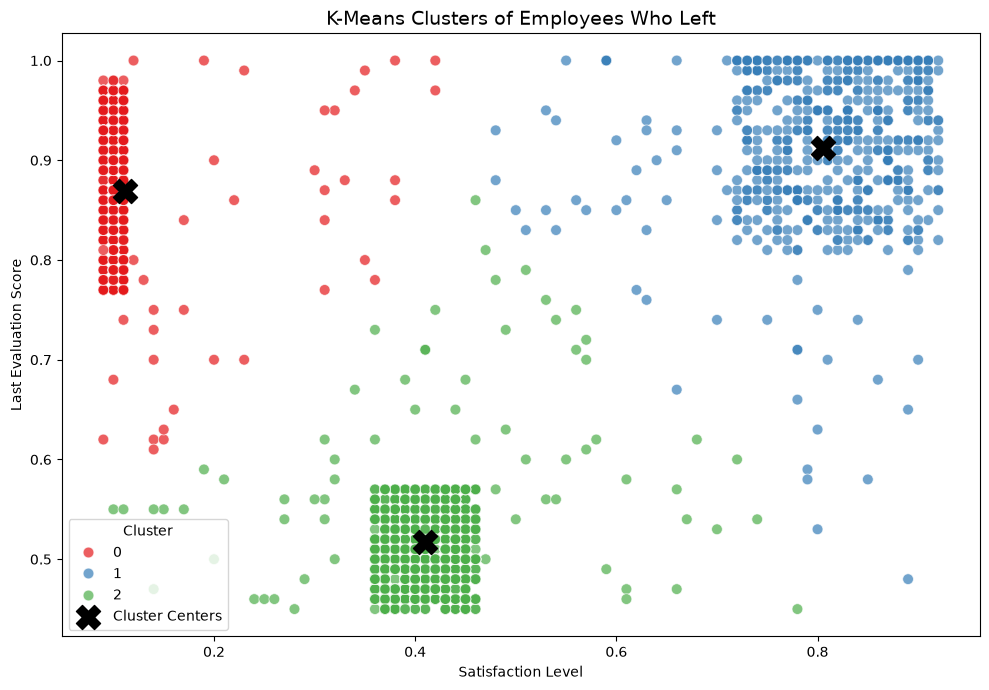

In [93]:
# Set the size of the chart
plt.figure(figsize=(10, 7))

# Create a scatter plot for the employee clusters
sns.scatterplot(
    data=employees_left,
    x="satisfaction_level",
    y="last_evaluation",
    hue="cluster",
    palette="Set1",
    s=60,
    alpha=0.7
)

# Plot the three cluster centers
plt.scatter(
    kmeans_model.cluster_centers_[:, 0],
    kmeans_model.cluster_centers_[:, 1],
    marker="X",
    s=300,
    c="black",
    label="Cluster Centers"
)

# Add the chart title and labels
plt.title(
    "K-Means Clusters of Employees Who Left",
    fontsize=14
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation Score")

# Display the legend
plt.legend(title="Cluster")

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

### Cluster Visualization Interpretation

The scatter plot visually confirms that K-means identified three distinct groups among employees who left the company.

**Cluster 0**, shown in red, is concentrated at very low satisfaction levels and relatively high evaluation scores. This group represents highly dissatisfied employees who were generally evaluated as strong performers.

**Cluster 1**, shown in blue, is concentrated at high satisfaction levels and high evaluation scores. These employees appeared satisfied and performed well but still left the company, suggesting that factors beyond satisfaction and performance may have influenced their departure.

**Cluster 2**, shown in green, is concentrated around moderately low satisfaction levels and lower evaluation scores. This is the largest employee group and may represent employees experiencing both engagement and performance challenges.

The black `X` markers represent the cluster centers and are positioned near the middle of each major employee group. Although some employees appear between the main clusters, the overall separation is clear.

The results demonstrate that employee turnover involves several different employee profiles. Therefore, retention actions should be tailored to the needs of each group rather than using one general strategy for all employees.


# 6. Data Preprocessing

Machine-learning models require the input features to be represented numerically.

The employee dataset contains two categorical variables, `Department` and `salary`. These variables will be separated from the numerical variables and converted into dummy variables using one-hot encoding.

The target variable, `left`, will be stored separately because it represents the outcome the models will predict.

## 6.1 Separate Numerical and Categorical Variables

The input variables are divided into numerical and categorical groups before encoding. The `left` column is excluded from the input features because it is the target variable.

In [94]:
# Define the categorical columns
categorical_columns = [
    "Department",
    "salary"
]

# Define the numerical input columns
# The target column 'left' is not included
numerical_columns = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company",
    "Work_accident",
    "promotion_last_5years"
]

# Create a DataFrame containing only categorical variables
categorical_data = df[categorical_columns].copy()

# Create a DataFrame containing only numerical input variables
numerical_data = df[numerical_columns].copy()

# Store the target variable separately
target = df["left"].copy()

# Display the selected columns
print("Categorical columns:")
print(categorical_data.columns.tolist())

print("\nNumerical columns:")
print(numerical_data.columns.tolist())

print("\nTarget variable:")
print(target.name)

# Display the shapes of the three datasets
print("\nCategorical data shape:", categorical_data.shape)
print("Numerical data shape:", numerical_data.shape)
print("Target shape:", target.shape)

Categorical columns:
['Department', 'salary']

Numerical columns:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

Target variable:
left

Categorical data shape: (11991, 2)
Numerical data shape: (11991, 7)
Target shape: (11991,)


## 6.2 Encode the Categorical Variables

One-hot encoding converts each category into a separate numerical column containing values of 0 or 1.

The `get_dummies()` function will be applied to the `Department` and `salary` variables. The first category from each variable will be omitted using `drop_first=True` to avoid creating redundant columns.

In [95]:
# Convert the categorical variables into dummy variables
encoded_categorical_data = pd.get_dummies(
    categorical_data,
    drop_first=True,
    dtype=int
)

# Display the first five encoded records
encoded_categorical_data.head()

,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,1
3,0,0,0,0,0,0,1,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,0


## 6.3 Combine the Preprocessed Variables

The numerical variables and the encoded categorical variables are combined into one feature dataset named `X`.

The target variable is stored separately as `y`. The resulting feature dataset contains only numerical values and is ready for the train-test split.

In [96]:
# Combine the numerical and encoded categorical variables
X = pd.concat(
    [
        numerical_data,
        encoded_categorical_data
    ],
    axis=1
)

# Store the target variable using the standard name y
y = target.copy()

# Display the dimensions of the final feature and target datasets
print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

# Confirm that all feature columns are numerical
print("\nFeature data types:")
print(X.dtypes)

# Display the first five preprocessed records
X.head()

Feature dataset shape: (11991, 18)
Target dataset shape: (11991,)

Feature data types:
satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_montly_hours        int64
time_spend_company          int64
Work_accident               int64
promotion_last_5years       int64
Department_RandD            int64
Department_accounting       int64
Department_hr               int64
Department_management       int64
Department_marketing        int64
Department_product_mng      int64
Department_sales            int64
Department_support          int64
Department_technical        int64
salary_low                  int64
salary_medium               int64
dtype: object


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,1,0,0,1,0


### Preprocessing Interpretation

The categorical variables were successfully separated from the numerical variables and converted into dummy variables using one-hot encoding.

The original dataset contained seven numerical predictor variables. One-hot encoding created nine Department dummy variables and two salary dummy variables. Combined, the final feature dataset contains 18 numerical input variables for 11,991 employees.

The `left` variable was stored separately as the target variable. All feature columns now contain numerical values, so the dataset is ready to be divided into training and testing sets.

Because `drop_first=True` was used, one category from each categorical variable was omitted as a reference category. The omitted categories are Department `IT` and salary `high`.


# 7. Stratified Train-Test Split

The preprocessed dataset is divided into training and testing sets.

The training dataset contains 80% of the records and will be used to train the machine-learning models. The testing dataset contains the remaining 20% and will be used to evaluate model performance on data that the models did not see during training.

A stratified split is used to preserve the proportion of employees who stayed and employees who left in both datasets. The random state is set to 123 so that the same split is produced each time the notebook is run.


In [97]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Divide the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# Display the dimensions of each dataset
print("Training feature dataset shape:", X_train.shape)
print("Testing feature dataset shape:", X_test.shape)
print("Training target dataset shape:", y_train.shape)
print("Testing target dataset shape:", y_test.shape)

Training feature dataset shape: (9592, 18)
Testing feature dataset shape: (2399, 18)
Training target dataset shape: (9592,)
Testing target dataset shape: (2399,)


## 7.1 Verify the Class Distribution

The class distributions in the training and testing sets are reviewed to confirm that stratification preserved the original proportion of employees who stayed and employees who left.

In [98]:
# Calculate the training class counts
training_counts = y_train.value_counts().sort_index()

# Calculate the testing class counts
testing_counts = y_test.value_counts().sort_index()

# Calculate the training class percentages
training_percentages = (
    y_train.value_counts(normalize=True).sort_index() * 100
)

# Calculate the testing class percentages
testing_percentages = (
    y_test.value_counts(normalize=True).sort_index() * 100
)

# Display the training distribution
print("Training target distribution:")
print(training_counts)

print("\nTraining target percentages:")
print(training_percentages.round(2))

# Display the testing distribution
print("\nTesting target distribution:")
print(testing_counts)

print("\nTesting target percentages:")
print(testing_percentages.round(2))

Training target distribution:
left
0    7999
1    1593
Name: count, dtype: int64

Training target percentages:
left
0    83.39
1    16.61
Name: proportion, dtype: float64

Testing target distribution:
left
0    2001
1     398
Name: count, dtype: int64

Testing target percentages:
left
0    83.41
1    16.59
Name: proportion, dtype: float64


### Train-Test Split Interpretation

The cleaned dataset was successfully divided into training and testing sets using an 80:20 ratio.

The training dataset contains 9,592 employee records, while the testing dataset contains 2,399 employee records.

The training set contains approximately 83.39% employees who stayed and 16.61% employees who left. The testing set contains approximately 83.41% employees who stayed and 16.59% employees who left.

These nearly identical percentages confirm that the stratified split preserved the original turnover distribution in both datasets.

The results also confirm that the target variable is imbalanced because employees who stayed substantially outnumber employees who left. SMOTE will therefore be applied only to the training dataset.


# 8. Handle Class Imbalance Using SMOTE

The training target is imbalanced because the number of employees who stayed is much larger than the number of employees who left.

An imbalanced dataset may cause a machine-learning model to favor the majority class and perform poorly when identifying employees who are likely to leave.

The Synthetic Minority Oversampling Technique, or SMOTE, creates new synthetic examples of the minority class based on existing minority-class observations.

SMOTE will be applied only to the training dataset. The testing dataset will remain unchanged so that model performance can be evaluated using the original employee distribution.


In [99]:
# Import the SMOTE technique
from imblearn.over_sampling import SMOTE

# Create the SMOTE object
smote = SMOTE(
    random_state=123
)

# Apply SMOTE only to the training dataset
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Display the dimensions before and after SMOTE
print("Training feature shape before SMOTE:", X_train.shape)
print("Training feature shape after SMOTE:", X_train_smote.shape)

print("\nTraining target shape before SMOTE:", y_train.shape)
print("Training target shape after SMOTE:", y_train_smote.shape)

Training feature shape before SMOTE: (9592, 18)
Training feature shape after SMOTE: (15998, 18)

Training target shape before SMOTE: (9592,)
Training target shape after SMOTE: (15998,)


## 8.2 Verify the Class Distribution After SMOTE

The training class distribution is reviewed after applying SMOTE.

A successful result should show an equal number of employees who stayed and employees who left. The testing dataset is not modified.

In [100]:
# Count each class after applying SMOTE
smote_class_counts = (
    y_train_smote
    .value_counts()
    .sort_index()
)

# Calculate the class percentages after SMOTE
smote_class_percentages = (
    y_train_smote
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Display the balanced class counts
print("Training target distribution after SMOTE:")
print(smote_class_counts)

# Display the balanced class percentages
print("\nTraining target percentages after SMOTE:")
print(smote_class_percentages.round(2))

# Confirm that the testing dataset was not changed
print("\nTesting target distribution remains unchanged:")
print(y_test.value_counts().sort_index())

Training target distribution after SMOTE:
left
0    7999
1    7999
Name: count, dtype: int64

Training target percentages after SMOTE:
left
0    50.0
1    50.0
Name: proportion, dtype: float64

Testing target distribution remains unchanged:
left
0    2001
1     398
Name: count, dtype: int64


### SMOTE Interpretation

Before applying SMOTE, the training dataset contained 7,999 employees who stayed and 1,593 employees who left. This represented a considerable class imbalance, with employees who left forming the minority class.

After applying SMOTE, the minority class increased to 7,999 records. The balanced training dataset now contains 7,999 employees in each class, representing an equal 50% distribution.

The number of training records increased from 9,592 to 15,998. The additional minority-class records are synthetic observations generated from patterns among existing employees who left.

SMOTE was applied only to the training dataset. The testing dataset remains unchanged with 2,001 employees who stayed and 398 employees who left. This ensures that model performance is evaluated using the original turnover distribution.


# 9. Logistic Regression Model

Logistic Regression is a supervised classification algorithm commonly used to predict a binary outcome.

In this project, the model will predict whether an employee:

* Stayed with the company (`left = 0`)
* Left the company (`left = 1`)

Because the input variables use different numerical scales, StandardScaler will be applied before Logistic Regression. For example, satisfaction values range from 0 to 1, while average monthly working hours may exceed 300.

## 9.1 Preliminary Five-Fold Cross-Validation

Five-fold cross-validation divides the balanced training dataset into five sections, called folds.

The model is trained five times. During each iteration, four folds are used for training and one fold is used for validation. Each fold is used once as the validation set.

This process provides a more reliable estimate of model performance than evaluating the model using only one training-validation split.


In [101]:
# Import the required Logistic Regression tools
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

# Create a pipeline that first scales the features
# and then trains the Logistic Regression model
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=123
            )
        )
    ]
)

# Create a stratified five-fold cross-validation method
five_fold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Define the performance metrics to calculate
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1_score": "f1",
    "roc_auc": "roc_auc"
}

# Perform five-fold cross-validation
logistic_cv_results = cross_validate(
    estimator=logistic_pipeline,
    X=X_train_smote,
    y=y_train_smote,
    cv=five_fold_cv,
    scoring=scoring_metrics
)

# Organize the score from each fold into a table
logistic_cv_table = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": logistic_cv_results["test_accuracy"],
        "Precision": logistic_cv_results["test_precision"],
        "Recall": logistic_cv_results["test_recall"],
        "F1 Score": logistic_cv_results["test_f1_score"],
        "ROC-AUC": logistic_cv_results["test_roc_auc"]
    }
)

# Display the score for each fold
print("Logistic Regression five-fold cross-validation results:")
display(logistic_cv_table.round(4))

# Calculate and display the average score across all five folds
logistic_cv_average = (
    logistic_cv_table
    .drop(columns="Fold")
    .mean()
)

print("\nAverage cross-validation scores:")
print(logistic_cv_average.round(4))

Logistic Regression five-fold cross-validation results:


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.8269,0.8117,0.8512,0.8310,0.8865
1,2,0.8188,0.8021,0.8462,0.8236,0.8783
2,3,0.8412,0.8223,0.8706,0.8458,0.8983
3,4,0.8237,0.8108,0.8443,0.8272,0.8851
4,5,0.8274,0.8207,0.8381,0.8293,0.8912



Average cross-validation scores:
Accuracy     0.8276
Precision    0.8135
Recall       0.8501
F1 Score     0.8314
ROC-AUC      0.8879
dtype: float64


### Preliminary Logistic Regression Cross-Validation Interpretation

The preliminary Logistic Regression model achieved an average cross-validation accuracy of approximately **82.76%**.

The average precision score was **81.35%**, while the average recall score was **85.01%**. The average F1 score was **83.14%**, and the average ROC-AUC score was **88.79%**.

The results were relatively consistent across the five folds. However, this preliminary cross-validation was performed after SMOTE had already been applied to the complete training dataset.

Applying SMOTE before creating the cross-validation folds may cause synthetic observations and closely related original observations to appear in different folds. This can introduce data leakage and produce overly optimistic validation results.

Therefore, these scores are retained as a preliminary comparison only. A revised leakage-safe cross-validation approach will be performed by placing SMOTE inside an imbalanced-learn pipeline so that synthetic records are created only from the training portion of each fold.



## 9.2 Initial Logistic Regression Test Evaluation

The preliminary Logistic Regression model is trained using the complete SMOTE-balanced training dataset and evaluated using the untouched testing dataset.

The testing dataset was not modified by SMOTE and preserves the original class distribution. Therefore, it provides a more realistic assessment of how the model performs on unseen employee records.

This initial test evaluation will also be compared with the preliminary cross-validation results to determine whether the validation method produced an overly optimistic estimate of model performance.


In [102]:
# Import the evaluation functions
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train the Logistic Regression pipeline
# using the complete balanced training dataset
logistic_pipeline.fit(
    X_train_smote,
    y_train_smote
)

# Predict whether each employee in the test data stayed or left
logistic_predictions = logistic_pipeline.predict(X_test)

# Predict the probability that each employee left
logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

# Display the classification report
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Stayed", "Left"],
        digits=4
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Stayed     0.9128    0.7851    0.8442      2001
        Left     0.3658    0.6231    0.4610       398

    accuracy                         0.7582      2399
   macro avg     0.6393    0.7041    0.6526      2399
weighted avg     0.8221    0.7582    0.7806      2399



In [103]:
# Calculate the Logistic Regression test metrics
logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_test_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_test_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_test_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_test_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

# Store the test results in a table
logistic_test_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            logistic_test_accuracy,
            logistic_test_precision,
            logistic_test_recall,
            logistic_test_f1,
            logistic_test_roc_auc
        ]
    }
)

# Display the test results
print("Logistic Regression Test Results:")
display(logistic_test_results.round(4))

Logistic Regression Test Results:


,Metric,Score
0,Accuracy,0.7582
1,Precision,0.3658
2,Recall,0.6231
3,F1 Score,0.4610
4,ROC-AUC,0.7843


### Initial Test Evaluation Interpretation

The Logistic Regression model achieved a test accuracy of approximately **75.82%** and a ROC-AUC score of approximately **78.43%**.

For employees who left the company, the model achieved a precision score of **36.58%**. This means that only about 37% of employees predicted to leave actually left, indicating that the model generated a considerable number of false-positive predictions.

The recall score for employees who left was **62.31%**, meaning that the model correctly identified approximately 62% of the employees who actually left. The F1 score was **46.10%**, reflecting the imbalance between the relatively low precision and moderate recall.

The test performance was substantially lower than the preliminary cross-validation performance. In particular, the preliminary cross-validation ROC-AUC was approximately 88.79%, compared with 78.43% on the untouched testing dataset.

This difference suggests that the preliminary cross-validation process may have produced an overly optimistic estimate of model performance. The cross-validation method will therefore be reviewed before the Logistic Regression results are finalized.


## 9.3 Methodological Review: Preventing Data Leakage

The preliminary five-fold cross-validation was performed using a training dataset that had already been balanced with SMOTE.

Although this approach uses balanced data, applying SMOTE before creating the cross-validation folds can introduce data leakage. SMOTE creates synthetic minority-class observations using relationships among existing training records. When the already-resampled dataset is later divided into folds, synthetic records and closely related original records may appear in different folds.

As a result, information related to the validation portion may indirectly influence the training portion, causing the cross-validation scores to appear higher than the model's actual performance on unseen data.

To avoid this problem, the cross-validation process will be repeated using an imbalanced-learn pipeline. Within each fold, the pipeline will:

1. Standardize only the training portion of the fold.
2. Apply SMOTE only to the training portion.
3. Train the Logistic Regression model.
4. Evaluate the model using the untouched validation portion.

The revised leakage-safe results will be used for final model comparison. The preliminary results are retained only to demonstrate the methodological review.


## 9.4: Revised Leakage-Safe Cross-Validation

In [104]:
# Import the required tools for leakage-safe cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Create a leakage-safe pipeline
logistic_pipeline_safe = ImbPipeline(
    steps=[
        # Step 1: Standardize the training features inside each fold
        ("scaler", StandardScaler()),

        # Step 2: Apply SMOTE only to the training portion of each fold
        ("smote", SMOTE(random_state=123)),

        # Step 3: Train the Logistic Regression model
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=123
            )
        )
    ]
)

# Create a stratified five-fold cross-validation method
five_fold_cv_safe = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Define the metrics that will be calculated
safe_scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1_score": "f1",
    "roc_auc": "roc_auc"
}

# Perform cross-validation using the ORIGINAL training data
# SMOTE is applied separately inside each training fold
logistic_safe_cv_results = cross_validate(
    estimator=logistic_pipeline_safe,
    X=X_train,
    y=y_train,
    cv=five_fold_cv_safe,
    scoring=safe_scoring_metrics
)

# Organize the results from each fold into a table
logistic_safe_cv_table = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": logistic_safe_cv_results["test_accuracy"],
        "Precision": logistic_safe_cv_results["test_precision"],
        "Recall": logistic_safe_cv_results["test_recall"],
        "F1 Score": logistic_safe_cv_results["test_f1_score"],
        "ROC-AUC": logistic_safe_cv_results["test_roc_auc"]
    }
)

# Display the result from each fold
print(
    "Revised Leakage-Safe Logistic Regression "
    "Cross-Validation Results:"
)

display(logistic_safe_cv_table.round(4))

# Calculate the average result across all five folds
logistic_safe_cv_average = (
    logistic_safe_cv_table
    .drop(columns="Fold")
    .mean()
)

print("\nAverage leakage-safe cross-validation scores:")
print(logistic_safe_cv_average.round(4))

Revised Leakage-Safe Logistic Regression Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.7702,0.4076,0.8433,0.5495,0.8438
1,2,0.7728,0.4123,0.8621,0.5578,0.8453
2,3,0.7706,0.4022,0.7893,0.5329,0.8303
3,4,0.7852,0.4244,0.8302,0.5617,0.8390
4,5,0.7904,0.4312,0.8150,0.5640,0.8438



Average leakage-safe cross-validation scores:
Accuracy     0.7778
Precision    0.4155
Recall       0.8280
F1 Score     0.5532
ROC-AUC      0.8404
dtype: float64


### Revised Cross-Validation Interpretation

The revised leakage-safe Logistic Regression model achieved an average cross-validation accuracy of approximately **77.78%**.

The average precision score was **41.55%**, meaning that approximately 42% of employees predicted to leave actually belonged to the turnover class. The lower precision indicates that the model produced a number of false-positive predictions.

The average recall score was **82.80%**, showing that the model successfully identified approximately 83% of employees who actually left. This is particularly important for employee-turnover prediction because a false negative would represent an at-risk employee who was not identified for possible retention action.

The average F1 score was **55.32%**, reflecting the balance between the model's high recall and lower precision. The average ROC-AUC score was **84.04%**, indicating good overall ability to distinguish employees who left from employees who stayed.

The revised scores are lower than the preliminary cross-validation results because the revised method prevents SMOTE-related data leakage. These leakage-safe results provide a more realistic and reliable estimate of Logistic Regression performance and will be used in the final model comparison.


## 9.5 Final Logistic Regression Test Evaluation

The leakage-safe Logistic Regression pipeline is now trained using the complete original training dataset.

During training, the pipeline standardizes the input features, applies SMOTE to balance the training classes, and trains the Logistic Regression model.

The model is then evaluated using the untouched testing dataset. The resulting test metrics will be retained for comparison with the Random Forest and Gradient Boosting models.


In [105]:
# Train the leakage-safe Logistic Regression pipeline
# using the original training dataset
logistic_pipeline_safe.fit(
    X_train,
    y_train
)

# Predict the class for each employee in the test dataset
logistic_final_predictions = (
    logistic_pipeline_safe.predict(X_test)
)

# Predict the probability that each employee will leave
logistic_final_probabilities = (
    logistic_pipeline_safe.predict_proba(X_test)[:, 1]
)

print("Final Logistic Regression model trained successfully.")
print("Number of test predictions:", len(logistic_final_predictions))

Final Logistic Regression model trained successfully.
Number of test predictions: 2399


## Generate the final classification report

In [106]:
# Generate the final Logistic Regression classification report
print("Final Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_final_predictions,
        target_names=["Stayed", "Left"],
        digits=4
    )
)

Final Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Stayed     0.9563    0.7661    0.8507      2001
        Left     0.4121    0.8241    0.5494       398

    accuracy                         0.7757      2399
   macro avg     0.6842    0.7951    0.7001      2399
weighted avg     0.8660    0.7757    0.8007      2399



## Calculate and save the final test metrics

In [107]:
# Calculate final Logistic Regression test metrics
logistic_final_accuracy = accuracy_score(
    y_test,
    logistic_final_predictions
)

logistic_final_precision = precision_score(
    y_test,
    logistic_final_predictions
)

logistic_final_recall = recall_score(
    y_test,
    logistic_final_predictions
)

logistic_final_f1 = f1_score(
    y_test,
    logistic_final_predictions
)

logistic_final_roc_auc = roc_auc_score(
    y_test,
    logistic_final_probabilities
)

# Store the final results in a table
logistic_final_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            logistic_final_accuracy,
            logistic_final_precision,
            logistic_final_recall,
            logistic_final_f1,
            logistic_final_roc_auc
        ]
    }
)

print("Final Logistic Regression Test Results:")
display(logistic_final_results.round(4))

Final Logistic Regression Test Results:


,Metric,Score
0,Accuracy,0.7757
1,Precision,0.4121
2,Recall,0.8241
3,F1 Score,0.5494
4,ROC-AUC,0.8318


## 9.6 Logistic Regression Classification Report Heatmap

The classification-report results are visualized using a heatmap.

The heatmap displays precision, recall, and F1 score separately for employees who stayed and employees who left. Values closer to 1 represent stronger model performance.


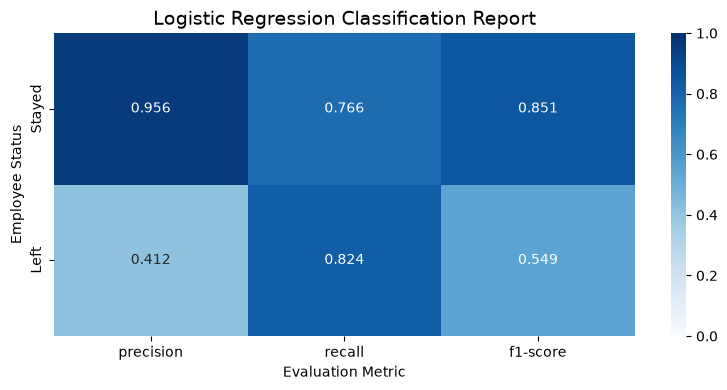

In [108]:
# Generate the classification report as a dictionary
logistic_report_dictionary = classification_report(
    y_test,
    logistic_final_predictions,
    target_names=["Stayed", "Left"],
    output_dict=True
)

# Convert the report into a DataFrame
logistic_report_df = pd.DataFrame(
    logistic_report_dictionary
).transpose()

# Select the class-level metrics for the heatmap
logistic_report_plot = logistic_report_df.loc[
    ["Stayed", "Left"],
    ["precision", "recall", "f1-score"]
]

# Create the heatmap
plt.figure(figsize=(8, 4))

sns.heatmap(
    logistic_report_plot,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(
    "Logistic Regression Classification Report",
    fontsize=14
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Employee Status")

plt.tight_layout()
plt.show()

### Final Logistic Regression Interpretation

The final Logistic Regression model achieved a test accuracy of approximately **77.57%** and a ROC-AUC score of approximately **83.18%**.

For employees who left, the model achieved a recall score of **82.41%**. This means that the model correctly identified approximately 82% of the employees who actually left the company. The strong recall is valuable for employee-turnover analysis because it reduces the number of at-risk employees who are missed.

The precision score for employees who left was **41.21%**. This means that approximately 41% of employees predicted to leave actually left. Therefore, the model produced a considerable number of false-positive alerts.

The F1 score for employees who left was **54.94%**, reflecting the trade-off between high recall and lower precision.

The test results closely match the revised leakage-safe cross-validation results. This consistency indicates that the corrected Logistic Regression pipeline generalizes reliably to unseen data.

Overall, Logistic Regression provides good turnover detection and prioritizes recall. However, its relatively low precision means that retention teams would need to investigate a larger number of employees, including some who may not actually leave.


# 10. Random Forest Classifier

Random Forest is an ensemble machine-learning algorithm that combines predictions from many decision trees.

Each decision tree examines different samples and combinations of employee features. The final classification is based on the combined results of the trees.

Random Forest can capture nonlinear relationships and interactions that Logistic Regression may not identify. This is useful because employee turnover may depend on complex combinations of satisfaction, workload, tenure, salary, and other characteristics.

## 10.1 Leakage-Safe Five-Fold Cross-Validation

Five-fold stratified cross-validation is used to evaluate the Random Forest model.

SMOTE is included inside an imbalanced-learn pipeline so that synthetic minority-class records are generated only from the training portion of each fold. The validation portion remains untouched, preventing data leakage.


In [109]:
# Import the Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create a leakage-safe Random Forest pipeline
random_forest_pipeline = ImbPipeline(
    steps=[
        # Apply SMOTE only to the training portion of each fold
        ("smote", SMOTE(random_state=123)),

        # Train the Random Forest model
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=123,
                n_jobs=-1
            )
        )
    ]
)

# Perform leakage-safe five-fold cross-validation
random_forest_cv_results = cross_validate(
    estimator=random_forest_pipeline,
    X=X_train,
    y=y_train,
    cv=five_fold_cv_safe,
    scoring=safe_scoring_metrics
)

# Organize the results from each fold into a table
random_forest_cv_table = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": random_forest_cv_results["test_accuracy"],
        "Precision": random_forest_cv_results["test_precision"],
        "Recall": random_forest_cv_results["test_recall"],
        "F1 Score": random_forest_cv_results["test_f1_score"],
        "ROC-AUC": random_forest_cv_results["test_roc_auc"]
    }
)

# Display the results from every fold
print(
    "Random Forest Leakage-Safe "
    "Five-Fold Cross-Validation Results:"
)

display(random_forest_cv_table.round(4))

# Calculate the average cross-validation scores
random_forest_cv_average = (
    random_forest_cv_table
    .drop(columns="Fold")
    .mean()
)

print("\nAverage Random Forest cross-validation scores:")
print(random_forest_cv_average.round(4))

Random Forest Leakage-Safe Five-Fold Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.9766,0.9419,0.9154,0.9285,0.9829
1,2,0.9750,0.9329,0.9154,0.9241,0.9834
2,3,0.9802,0.9698,0.9088,0.9383,0.9733
3,4,0.9833,0.9735,0.9245,0.9484,0.9873
4,5,0.9802,0.9668,0.9122,0.9387,0.9783



Average Random Forest cross-validation scores:
Accuracy     0.9790
Precision    0.9570
Recall       0.9153
F1 Score     0.9356
ROC-AUC      0.9810
dtype: float64


### Random Forest Cross-Validation Interpretation

The Random Forest model achieved an average cross-validation accuracy of approximately **97.90%**.

The average precision score was **95.70%**, meaning that approximately 96% of employees predicted to leave actually belonged to the turnover class. This indicates that the model generated relatively few false-positive predictions.

The average recall score was **91.53%**, showing that the model successfully identified approximately 92% of employees who actually left. The average F1 score was **93.56%**, demonstrating a strong balance between precision and recall.

The average ROC-AUC score was **98.10%**, indicating excellent ability to distinguish employees who left from employees who stayed.

The results were consistent across all five folds. This suggests that the Random Forest model performs reliably across different portions of the training data.

Compared with Logistic Regression, Random Forest achieved considerably higher accuracy, precision, F1 score, and ROC-AUC. This indicates that employee turnover may depend on nonlinear relationships and interactions that Random Forest can capture more effectively.


## 10.2 Final Random Forest Test Evaluation

After completing leakage-safe five-fold cross-validation, the Random Forest pipeline is trained using the complete original training dataset.

SMOTE is applied inside the pipeline to balance the training classes. The trained model is then evaluated using the untouched testing dataset, which preserves the original employee-turnover distribution.

The final predictions and turnover probabilities will also be saved for later ROC-curve, confusion-matrix, and model-comparison analysis.


In [110]:
# Train the Random Forest pipeline
# using the original training dataset
random_forest_pipeline.fit(
    X_train,
    y_train
)

# Predict the employee status in the testing dataset
random_forest_predictions = (
    random_forest_pipeline.predict(X_test)
)

# Predict the probability that each employee will leave
random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)

# Confirm that predictions were created
print("Final Random Forest model trained successfully.")
print(
    "Number of test predictions:",
    len(random_forest_predictions)
)

Final Random Forest model trained successfully.
Number of test predictions: 2399


## 10.3 Random Forest Classification Report

The classification report evaluates the final Random Forest model separately for employees who stayed and employees who left.

The report includes precision, recall, F1 score, and support for each employee class.

In [111]:
# Display the final Random Forest classification report
print("Final Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["Stayed", "Left"],
        digits=4
    )
)

Final Random Forest Classification Report:

              precision    recall  f1-score   support

      Stayed     0.9816    0.9840    0.9828      2001
        Left     0.9186    0.9070    0.9128       398

    accuracy                         0.9712      2399
   macro avg     0.9501    0.9455    0.9478      2399
weighted avg     0.9711    0.9712    0.9712      2399



## 0.4: Calculate the Final Test Metrics

In [112]:
# Calculate the final Random Forest test metrics
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

# Store the results in a table
random_forest_test_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            random_forest_accuracy,
            random_forest_precision,
            random_forest_recall,
            random_forest_f1,
            random_forest_roc_auc
        ]
    }
)

# Display the results
print("Final Random Forest Test Results:")
display(random_forest_test_results.round(4))

Final Random Forest Test Results:


,Metric,Score
0,Accuracy,0.9712
1,Precision,0.9186
2,Recall,0.9070
3,F1 Score,0.9128
4,ROC-AUC,0.9735


## 10.5 Random Forest Classification Report Heatmap

The Random Forest classification-report metrics are displayed using a heatmap.

The heatmap makes it easier to compare precision, recall, and F1 score for employees who stayed and employees who left.

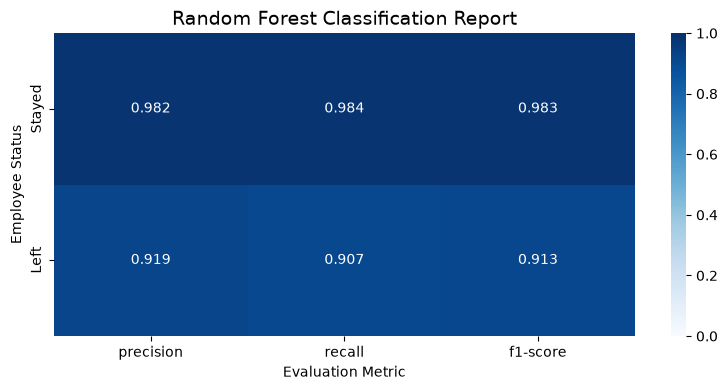

In [113]:
# Generate the classification report as a dictionary
random_forest_report_dictionary = classification_report(
    y_test,
    random_forest_predictions,
    target_names=["Stayed", "Left"],
    output_dict=True
)

# Convert the report into a DataFrame
random_forest_report_df = pd.DataFrame(
    random_forest_report_dictionary
).transpose()

# Select the class-level metrics for the heatmap
random_forest_report_plot = random_forest_report_df.loc[
    ["Stayed", "Left"],
    ["precision", "recall", "f1-score"]
]

# Create the heatmap
plt.figure(figsize=(8, 4))

sns.heatmap(
    random_forest_report_plot,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(
    "Random Forest Classification Report",
    fontsize=14
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Employee Status")

plt.tight_layout()
plt.show()

### Final Random Forest Interpretation

The final Random Forest model achieved a test accuracy of approximately **97.12%** and a ROC-AUC score of approximately **97.35%**.

For employees who left the company, the model achieved a precision score of **91.86%**. This means that approximately 92% of employees predicted to leave actually belonged to the turnover class, indicating relatively few false-positive predictions.

The recall score for employees who left was **90.70%**, showing that the model correctly identified approximately 91% of the employees who actually left. The F1 score was **91.28%**, demonstrating an excellent balance between precision and recall.

For employees who stayed, the model achieved precision, recall, and F1 scores above 98%, showing very strong performance for the majority class as well.

The test results are slightly lower than the five-fold cross-validation results, but the difference is small. This suggests that the Random Forest model generalizes well to unseen employee data without substantial overfitting.

Compared with Logistic Regression, Random Forest achieved substantially higher accuracy, precision, recall, F1 score, and ROC-AUC. This indicates that Random Forest captures nonlinear relationships and interactions among employee characteristics more effectively.


# 11. Gradient Boosting Classifier

Gradient Boosting is an ensemble machine-learning algorithm that builds a sequence of decision trees.

Each new tree focuses on correcting errors made by the previous trees. The combined model can identify complex and nonlinear relationships between employee characteristics and turnover.

Gradient Boosting may be particularly useful when turnover depends on interactions among satisfaction, workload, tenure, evaluation, salary, and department.

## 11.1 Leakage-Safe Five-Fold Cross-Validation

The Gradient Boosting model is evaluated using stratified five-fold cross-validation.

SMOTE is included inside an imbalanced-learn pipeline so that synthetic minority-class records are generated only from the training portion of each fold. The validation portion remains unchanged, preventing data leakage.


In [114]:
# Import the Gradient Boosting model
from sklearn.ensemble import GradientBoostingClassifier

# Create a leakage-safe Gradient Boosting pipeline
gradient_boosting_pipeline = ImbPipeline(
    steps=[
        # Apply SMOTE only to the training portion of each fold
        ("smote", SMOTE(random_state=123)),

        # Train the Gradient Boosting model
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=123
            )
        )
    ]
)

# Perform leakage-safe five-fold cross-validation
gradient_boosting_cv_results = cross_validate(
    estimator=gradient_boosting_pipeline,
    X=X_train,
    y=y_train,
    cv=five_fold_cv_safe,
    scoring=safe_scoring_metrics
)

# Organize the results from each fold into a table
gradient_boosting_cv_table = pd.DataFrame(
    {
        "Fold": range(1, 6),
        "Accuracy": gradient_boosting_cv_results["test_accuracy"],
        "Precision": gradient_boosting_cv_results["test_precision"],
        "Recall": gradient_boosting_cv_results["test_recall"],
        "F1 Score": gradient_boosting_cv_results["test_f1_score"],
        "ROC-AUC": gradient_boosting_cv_results["test_roc_auc"]
    }
)

# Display the result from each fold
print(
    "Gradient Boosting Leakage-Safe "
    "Five-Fold Cross-Validation Results:"
)

display(gradient_boosting_cv_table.round(4))

# Calculate the average cross-validation scores
gradient_boosting_cv_average = (
    gradient_boosting_cv_table
    .drop(columns="Fold")
    .mean()
)

print("\nAverage Gradient Boosting cross-validation scores:")
print(gradient_boosting_cv_average.round(4))

Gradient Boosting Leakage-Safe Five-Fold Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.9713,0.8929,0.9404,0.9160,0.9833
1,2,0.9640,0.8634,0.9310,0.8959,0.9850
2,3,0.9635,0.8669,0.9214,0.8933,0.9787
3,4,0.9677,0.8699,0.9465,0.9066,0.9877
4,5,0.9698,0.8919,0.9310,0.9110,0.9831



Average Gradient Boosting cross-validation scores:
Accuracy     0.9673
Precision    0.8770
Recall       0.9341
F1 Score     0.9046
ROC-AUC      0.9836
dtype: float64


### Gradient Boosting Cross-Validation Interpretation

The Gradient Boosting model achieved an average cross-validation accuracy of approximately **96.73%**.

The average precision score was **87.70%**, meaning that approximately 88% of employees predicted to leave actually belonged to the turnover class. The average recall score was **93.41%**, indicating that the model successfully identified approximately 93% of employees who actually left.

The average F1 score was **90.46%**, demonstrating a strong balance between precision and recall. The average ROC-AUC score was **98.36%**, indicating excellent ability to distinguish employees who left from employees who stayed.

The results were relatively consistent across the five validation folds, suggesting stable performance across different portions of the training dataset.

Compared with Random Forest, Gradient Boosting achieved higher recall and a slightly higher ROC-AUC score. However, Random Forest achieved higher accuracy, precision, and F1 score. The final decision regarding the best model will be based on performance on the untouched testing dataset and the business importance of identifying employees at risk of leaving.


## 11.2 Final Gradient Boosting Test Evaluation

After completing leakage-safe five-fold cross-validation, the Gradient Boosting pipeline is trained using the complete original training dataset.

SMOTE is applied inside the pipeline to balance the training classes. The trained model is then evaluated using the untouched testing dataset, which preserves the original employee-turnover distribution.

The model's class predictions and turnover probabilities will be saved for later model comparison, ROC-curve analysis, confusion-matrix analysis, and employee risk classification.


In [115]:
# Train the Gradient Boosting pipeline
# using the original training dataset
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

# Predict the employee status in the testing dataset
gradient_boosting_predictions = (
    gradient_boosting_pipeline.predict(X_test)
)

# Predict the probability that each employee will leave
gradient_boosting_probabilities = (
    gradient_boosting_pipeline.predict_proba(X_test)[:, 1]
)

# Confirm that predictions were created
print("Final Gradient Boosting model trained successfully.")
print(
    "Number of test predictions:",
    len(gradient_boosting_predictions)
)

Final Gradient Boosting model trained successfully.
Number of test predictions: 2399


## 11.3 Gradient Boosting Classification Report

The classification report evaluates the final Gradient Boosting model separately for employees who stayed and employees who left.

The report includes precision, recall, F1 score, and support for each employee class.

In [116]:
# Display the final Gradient Boosting classification report
print("Final Gradient Boosting Classification Report:\n")

print(
    classification_report(
        y_test,
        gradient_boosting_predictions,
        target_names=["Stayed", "Left"],
        digits=4
    )
)

Final Gradient Boosting Classification Report:

              precision    recall  f1-score   support

      Stayed     0.9832    0.9680    0.9756      2001
        Left     0.8508    0.9171    0.8827       398

    accuracy                         0.9596      2399
   macro avg     0.9170    0.9426    0.9291      2399
weighted avg     0.9613    0.9596    0.9602      2399



## 11.4: Calculate the Final Test Metrics

In [117]:
# Calculate the final Gradient Boosting test metrics
gradient_boosting_accuracy = accuracy_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_precision = precision_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_recall = recall_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_f1 = f1_score(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_probabilities
)

# Store the results in a table
gradient_boosting_test_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Score": [
            gradient_boosting_accuracy,
            gradient_boosting_precision,
            gradient_boosting_recall,
            gradient_boosting_f1,
            gradient_boosting_roc_auc
        ]
    }
)

# Display the results
print("Final Gradient Boosting Test Results:")
display(gradient_boosting_test_results.round(4))

Final Gradient Boosting Test Results:


,Metric,Score
0,Accuracy,0.9596
1,Precision,0.8508
2,Recall,0.9171
3,F1 Score,0.8827
4,ROC-AUC,0.9771


## 11.5 Gradient Boosting Classification Report Heatmap

The Gradient Boosting classification-report metrics are visualized using a heatmap.

The chart makes it easier to compare precision, recall, and F1 score for employees who stayed and employees who left.

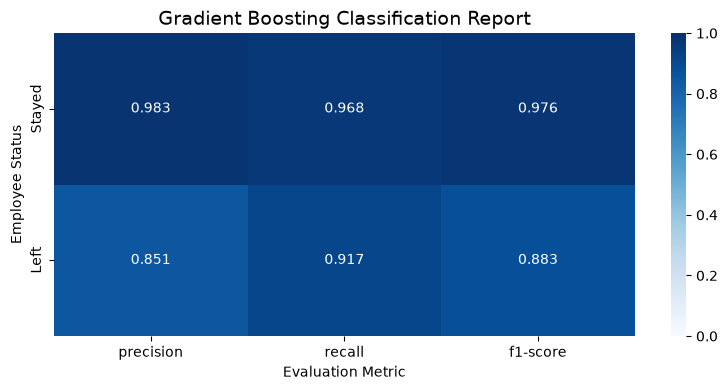

In [118]:
# Generate the classification report as a dictionary
gradient_boosting_report_dictionary = classification_report(
    y_test,
    gradient_boosting_predictions,
    target_names=["Stayed", "Left"],
    output_dict=True
)

# Convert the report into a DataFrame
gradient_boosting_report_df = pd.DataFrame(
    gradient_boosting_report_dictionary
).transpose()

# Select the class-level metrics for the heatmap
gradient_boosting_report_plot = gradient_boosting_report_df.loc[
    ["Stayed", "Left"],
    ["precision", "recall", "f1-score"]
]

# Create the heatmap
plt.figure(figsize=(8, 4))

sns.heatmap(
    gradient_boosting_report_plot,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(
    "Gradient Boosting Classification Report",
    fontsize=14
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Employee Status")

plt.tight_layout()
plt.show()

### Final Gradient Boosting Interpretation

The final Gradient Boosting model achieved a test accuracy of approximately **95.96%** and a ROC-AUC score of approximately **97.71%**.

For employees who left the company, the model achieved a precision score of **85.08%**. This means that approximately 85% of employees predicted to leave actually belonged to the turnover class.

The recall score for employees who left was **91.71%**, indicating that the model successfully identified approximately 92% of the employees who actually left. This strong recall is important because it reduces the number of at-risk employees who are missed.

The F1 score for employees who left was **88.27%**, demonstrating a strong balance between precision and recall.

The test results are close to the five-fold cross-validation results, suggesting that the Gradient Boosting model generalizes well to unseen employee data.

Compared with Random Forest, Gradient Boosting achieved slightly higher recall and ROC-AUC. However, Random Forest achieved higher accuracy, precision, and F1 score. A complete model comparison, including ROC curves and confusion matrices, will be performed before selecting the best model.


# 12. Model Evaluation and Comparison

The final test results from Logistic Regression, Random Forest, and Gradient Boosting are compared to identify the strongest employee-turnover model.

The comparison includes:

* Accuracy
* Precision
* Recall
* F1 score
* ROC-AUC

Because employee turnover is an imbalanced classification problem, accuracy alone is not sufficient. Precision, recall, F1 score, and ROC-AUC must also be considered when selecting the best model.

## 12.1 Final Test-Metric Comparison

The final test metrics from all three models are combined into one table for direct comparison.


In [119]:
# Create a comparison table using the final test results
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Gradient Boosting"
        ],
        "Accuracy": [
            logistic_final_accuracy,
            random_forest_accuracy,
            gradient_boosting_accuracy
        ],
        "Precision": [
            logistic_final_precision,
            random_forest_precision,
            gradient_boosting_precision
        ],
        "Recall": [
            logistic_final_recall,
            random_forest_recall,
            gradient_boosting_recall
        ],
        "F1 Score": [
            logistic_final_f1,
            random_forest_f1,
            gradient_boosting_f1
        ],
        "ROC-AUC": [
            logistic_final_roc_auc,
            random_forest_roc_auc,
            gradient_boosting_roc_auc
        ]
    }
)

# Display the model-comparison table
print("Final Model Test-Performance Comparison:")
display(model_comparison.round(4))

Final Model Test-Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7757,0.4121,0.8241,0.5494,0.8318
1,Random Forest,0.9712,0.9186,0.9070,0.9128,0.9735
2,Gradient Boosting,0.9596,0.8508,0.9171,0.8827,0.9771


### Test-Performance Comparison Interpretation

The three models produced noticeably different results on the untouched testing dataset.

Logistic Regression achieved an accuracy of **77.57%**, precision of **41.21%**, recall of **82.41%**, F1 score of **54.94%**, and ROC-AUC of **83.18%**. Although the model identified many employees who left, its low precision resulted in a considerable number of false-positive predictions.

Random Forest achieved the highest accuracy of **97.12%**, the highest precision of **91.86%**, and the highest F1 score of **91.28%**. It also achieved a strong recall of **90.70%** and ROC-AUC of **97.35%**.

Gradient Boosting achieved an accuracy of **95.96%**, precision of **85.08%**, recall of **91.71%**, F1 score of **88.27%**, and ROC-AUC of **97.71%**. It achieved the highest recall and ROC-AUC among the three models.

The results show that Random Forest provides the strongest overall balance between precision and recall, while Gradient Boosting identifies a slightly larger percentage of employees who actually leave.

A final model decision will be made after reviewing the ROC curves and confusion matrices.


## 12.2 ROC Curve and AUC Comparison

The Receiver Operating Characteristic, or ROC, curve evaluates how well a classification model distinguishes between employees who stayed and employees who left across different probability thresholds.

The vertical axis represents the true-positive rate, which is equivalent to recall. The horizontal axis represents the false-positive rate.

A stronger model produces a curve closer to the upper-left corner. The Area Under the Curve, or AUC, summarizes the model's overall ability to distinguish the two employee classes.

An AUC value close to 1 indicates excellent discrimination, while a value close to 0.5 indicates performance similar to random guessing.


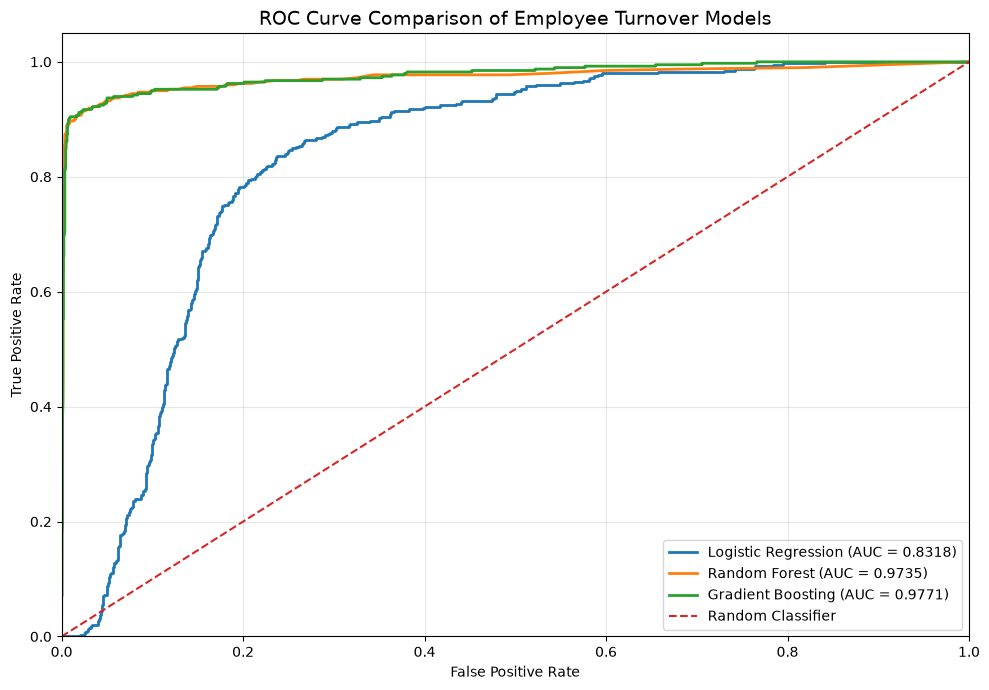

In [120]:
# Import the ROC-curve function
from sklearn.metrics import roc_curve

# Calculate the ROC points for Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_final_probabilities
)

# Calculate the ROC points for Random Forest
random_forest_fpr, random_forest_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

# Calculate the ROC points for Gradient Boosting
gradient_boosting_fpr, gradient_boosting_tpr, _ = roc_curve(
    y_test,
    gradient_boosting_probabilities
)

# Create the ROC-curve chart
plt.figure(figsize=(10, 7))

# Plot the Logistic Regression ROC curve
plt.plot(
    logistic_fpr,
    logistic_tpr,
    linewidth=2,
    label=(
        "Logistic Regression "
        f"(AUC = {logistic_final_roc_auc:.4f})"
    )
)

# Plot the Random Forest ROC curve
plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    linewidth=2,
    label=(
        "Random Forest "
        f"(AUC = {random_forest_roc_auc:.4f})"
    )
)

# Plot the Gradient Boosting ROC curve
plt.plot(
    gradient_boosting_fpr,
    gradient_boosting_tpr,
    linewidth=2,
    label=(
        "Gradient Boosting "
        f"(AUC = {gradient_boosting_roc_auc:.4f})"
    )
)

# Add a diagonal line representing random prediction
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

# Add the chart title and axis labels
plt.title(
    "ROC Curve Comparison of Employee Turnover Models",
    fontsize=14
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Set the visible axis ranges
plt.xlim([0, 1])
plt.ylim([0, 1.05])

# Add a legend and grid
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Adjust the layout and display the chart
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The ROC curves show that all three models perform better than random classification because their curves remain above the diagonal reference line.

Gradient Boosting achieved the highest ROC-AUC score of **0.9771**, indicating excellent ability to distinguish employees who left from employees who stayed.

Random Forest followed very closely with a ROC-AUC score of **0.9735**. Its curve is also concentrated near the upper-left corner, showing excellent classification performance.

Logistic Regression achieved a lower ROC-AUC score of **0.8318**. Although this still indicates good discriminatory ability, its ROC curve is noticeably below the Random Forest and Gradient Boosting curves.

Based only on ROC-AUC, Gradient Boosting performs slightly better than Random Forest. However, the difference between the two models is small. ROC-AUC alone should not determine the final model because precision, recall, F1 score, and the number of false-positive and false-negative predictions must also be considered.


## 12.3 Confusion Matrix Comparison

A confusion matrix shows the number of correct and incorrect predictions made by a classification model.

For employee-turnover prediction, the matrix contains four outcomes:

* **True Negative:** An employee stayed, and the model correctly predicted that the employee would stay.
* **False Positive:** An employee stayed, but the model incorrectly predicted that the employee would leave.
* **False Negative:** An employee left, but the model incorrectly predicted that the employee would stay.
* **True Positive:** An employee left, and the model correctly predicted that the employee would leave.

False negatives are especially important in employee-turnover analysis because they represent employees who actually left but were not identified as being at risk.


In [121]:
# Import the confusion-matrix function
from sklearn.metrics import confusion_matrix

# Calculate the Logistic Regression confusion matrix
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_final_predictions
)

# Calculate the Random Forest confusion matrix
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

# Calculate the Gradient Boosting confusion matrix
gradient_boosting_confusion_matrix = confusion_matrix(
    y_test,
    gradient_boosting_predictions
)

# Display the confusion matrices
print("Logistic Regression Confusion Matrix:")
print(logistic_confusion_matrix)

print("\nRandom Forest Confusion Matrix:")
print(random_forest_confusion_matrix)

print("\nGradient Boosting Confusion Matrix:")
print(gradient_boosting_confusion_matrix)

Logistic Regression Confusion Matrix:
[[1533  468]
 [  70  328]]

Random Forest Confusion Matrix:
[[1969   32]
 [  37  361]]

Gradient Boosting Confusion Matrix:
[[1937   64]
 [  33  365]]


##  12.3.3: Plot the confusion matrices

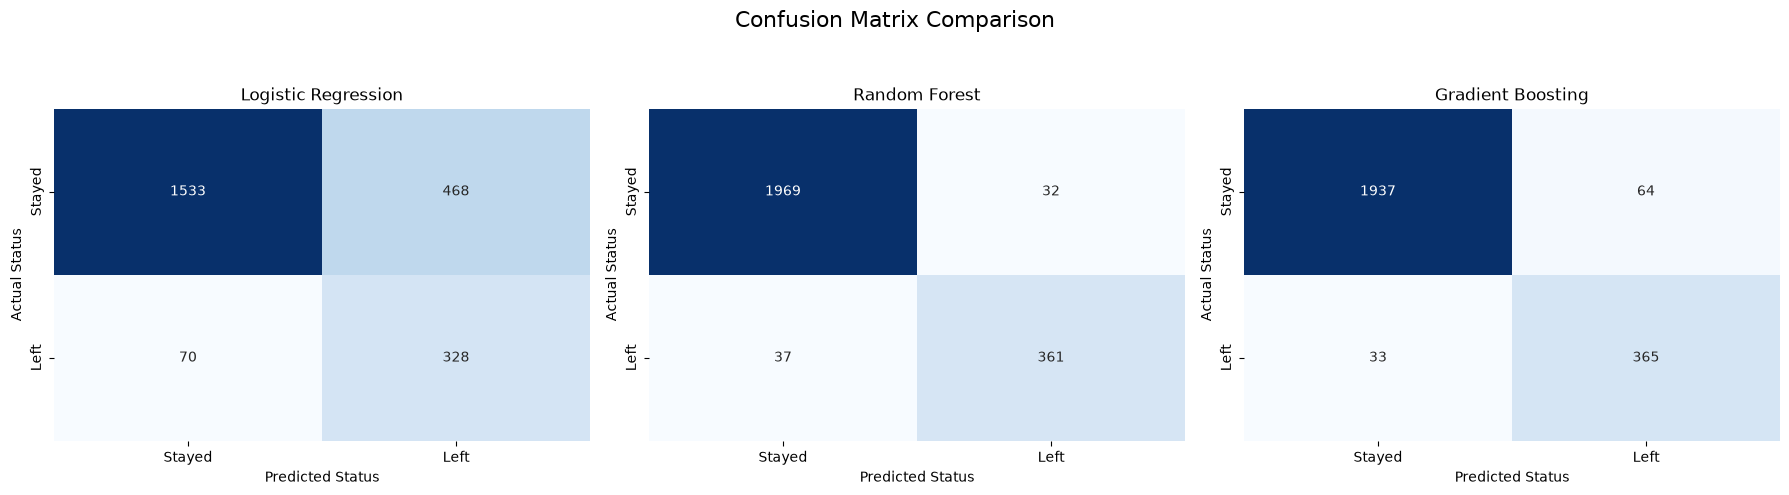

In [122]:
# Create one figure containing three confusion-matrix charts
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Store the matrices and titles together
confusion_matrices = [
    logistic_confusion_matrix,
    random_forest_confusion_matrix,
    gradient_boosting_confusion_matrix
]

model_titles = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
]

# Create one heatmap for each model
for axis, matrix, title in zip(
    axes,
    confusion_matrices,
    model_titles
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )

    axis.set_title(title)
    axis.set_xlabel("Predicted Status")
    axis.set_ylabel("Actual Status")

# Add an overall title
fig.suptitle(
    "Confusion Matrix Comparison",
    fontsize=16
)

# Prevent the charts from overlapping
plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

# Display the charts
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show substantial differences in the types of errors produced by the three models.

**Logistic Regression** correctly classified 1,533 employees who stayed and 328 employees who left. However, it incorrectly predicted that 468 employees would leave even though they stayed. It also failed to identify 70 employees who actually left. Logistic Regression therefore produced the largest number of false positives and false negatives.

**Random Forest** correctly classified 1,969 employees who stayed and 361 employees who left. It produced only 32 false positives and 37 false negatives. This model generated the fewest false-positive predictions and achieved a strong balance between correctly identifying leavers and avoiding unnecessary turnover alerts.

**Gradient Boosting** correctly classified 1,937 employees who stayed and 365 employees who left. It produced 64 false positives and 33 false negatives. Gradient Boosting missed four fewer employees who left than Random Forest, but it generated twice as many false-positive predictions.

Overall, Random Forest produced the strongest balance of correct predictions and classification errors. Gradient Boosting achieved slightly better detection of employees who left, while Random Forest produced substantially fewer false alerts.


## 12.4 Precision Versus Recall

Recall should be prioritized when evaluating employee-turnover models.

Recall measures the percentage of employees who actually left and were correctly identified by the model. A false-negative prediction represents an employee who left but was incorrectly predicted to stay. This type of error is particularly important because the company would not have an opportunity to investigate the employee's concerns or provide a targeted retention intervention.

Precision measures the percentage of employees predicted to leave who actually left. Low precision creates false-positive alerts and may cause HR teams to spend time and resources investigating employees who are not truly at risk.

Although recall is the more important individual metric for this business problem, precision cannot be ignored. A practical turnover model should identify most employees who are likely to leave while also limiting unnecessary retention alerts. Therefore, recall, precision, and F1 score should be considered together when selecting the final model.


## 12.5 Best Model Selection

Random Forest is selected as the best overall employee-turnover model.

Random Forest achieved the highest test accuracy of **97.12%**, the highest precision of **91.86%**, and the highest F1 score of **91.28%**. It also achieved a strong recall score of **90.70%** and a ROC-AUC score of **97.35%**.

Gradient Boosting achieved slightly higher recall and ROC-AUC. It identified 365 of the 398 employees who left, while Random Forest identified 361. Therefore, Gradient Boosting detected four additional employee departures.

However, Gradient Boosting produced 64 false-positive predictions, compared with only 32 for Random Forest. This means that Gradient Boosting generated twice as many unnecessary turnover alerts in exchange for identifying four additional leavers.

Random Forest provides the strongest practical balance between identifying employees at risk and limiting false alerts. Its high precision, recall, F1 score, accuracy, and ROC-AUC make it the most suitable model for employee-turnover prediction.

Gradient Boosting remains a strong alternative when the organization places the greatest possible emphasis on minimizing false negatives and has sufficient resources to investigate additional alerts.


# 13. Employee Turnover Risk Zones

The selected Random Forest model is used to estimate the probability that each employee in the testing dataset will leave the company.

Each employee is assigned to one of four turnover-risk zones:

- Safe Zone — probability below 20%
- Low-Risk Zone — probability from 20% to below 60%
- Medium-Risk Zone — probability from 60% to below 90%
- High-Risk Zone — probability of 90% or higher

These zones can help the HR department prioritize retention actions according to the estimated level of turnover risk.

In [123]:
# Create a new dataset containing the original employee information
# for the employees included in the testing dataset
employee_risk_results = df.loc[X_test.index].copy()

# Add the actual employee outcome
employee_risk_results["actual_left"] = y_test.values

# Add the Random Forest predicted class
employee_risk_results["predicted_left"] = (
    random_forest_predictions
)

# Add the predicted probability of leaving
employee_risk_results["turnover_probability"] = (
    random_forest_probabilities
)

# Convert the probability into a percentage
employee_risk_results["risk_score_percent"] = (
    employee_risk_results["turnover_probability"] * 100
).round(2)

# Display the first five employee-risk records
employee_risk_results.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,actual_left,predicted_left,turnover_probability,risk_score_percent
8569,0.82,0.95,6,191,6,0,0,0,accounting,medium,0,0,0.105,10.5
5747,0.18,0.86,5,267,4,0,0,0,accounting,medium,0,0,0.265,26.5
3985,0.63,0.98,4,160,2,0,0,0,sales,medium,0,0,0.030,3.0
1776,0.43,0.51,2,149,3,1,1,0,accounting,medium,1,1,0.900,90.0
10499,0.51,0.98,4,245,3,0,0,0,support,medium,0,0,0.010,1.0


### Turnover Probability Interpretation

The selected Random Forest model generated a turnover probability for each of the 2,399 employees in the testing dataset.

The probability values range from 0 to 1 and represent the model's estimated likelihood that an employee will leave. These values were also converted into percentage risk scores to make the results easier to interpret.

The dataset contains the employee's actual turnover outcome, the model's predicted outcome, and the predicted turnover probability. This allows HR to compare the model's prediction with the actual result and prioritize employees according to their estimated risk level.

The original dataset index was retained so that each prediction can be traced back to the corresponding employee record.


## 13.2 Assign Employee Turnover Risk Zones

Each employee is assigned to one of four risk zones based on the Random Forest turnover probability.

The zone boundaries are defined as follows:

* **Safe Zone:** Risk score below 20%
* **Low-Risk Zone:** Risk score from 20% to below 60%
* **Medium-Risk Zone:** Risk score from 60% to below 90%
* **High-Risk Zone:** Risk score of 90% or higher

The risk zones provide HR with an easier way to prioritize employees for different levels of monitoring and retention support.


In [124]:
# Define the boundaries for the four turnover-risk zones
risk_bins = [
    float("-inf"),
    20,
    60,
    90,
    float("inf")
]

# Define the name of each risk zone
risk_labels = [
    "Safe Zone",
    "Low-Risk Zone",
    "Medium-Risk Zone",
    "High-Risk Zone"
]

# Assign each employee to a risk zone
employee_risk_results["risk_zone"] = pd.cut(
    employee_risk_results["risk_score_percent"],
    bins=risk_bins,
    labels=risk_labels,
    right=False
)

# Display selected columns from the first 10 employees
employee_risk_results[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "Department",
        "salary",
        "actual_left",
        "predicted_left",
        "risk_score_percent",
        "risk_zone"
    ]
].head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,Department,salary,actual_left,predicted_left,risk_score_percent,risk_zone
8569,0.82,0.95,6,191,accounting,medium,0,0,10.5,Safe Zone
5747,0.18,0.86,5,267,accounting,medium,0,0,26.5,Low-Risk Zone
3985,0.63,0.98,4,160,sales,medium,0,0,3.0,Safe Zone
1776,0.43,0.51,2,149,accounting,medium,1,1,90.0,High-Risk Zone
10499,0.51,0.98,4,245,support,medium,0,0,1.0,Safe Zone
1533,0.83,0.92,4,235,sales,low,1,1,99.5,High-Risk Zone
8554,0.20,0.90,3,218,sales,low,0,0,12.0,Safe Zone
6154,0.74,0.84,3,239,technical,low,0,0,3.0,Safe Zone
4230,0.98,0.50,4,264,technical,high,0,0,1.0,Safe Zone
7910,0.80,1.00,3,177,technical,medium,0,0,2.5,Safe Zone


## 13.3 Review the Risk-Zone Distribution

The number and percentage of employees assigned to each risk zone are calculated.

This distribution shows how many employees may require routine monitoring, preventive engagement, targeted retention action, or immediate intervention.

In [125]:
# Count the number of employees in each risk zone
risk_zone_counts = (
    employee_risk_results["risk_zone"]
    .value_counts()
    .reindex(risk_labels)
)

# Calculate the percentage of employees in each risk zone
risk_zone_percentages = (
    employee_risk_results["risk_zone"]
    .value_counts(normalize=True)
    .reindex(risk_labels) * 100
)

# Create a risk-zone summary table
risk_zone_summary = pd.DataFrame(
    {
        "Risk Zone": risk_labels,
        "Number of Employees": risk_zone_counts.values,
        "Percentage of Test Employees": (
            risk_zone_percentages.values
        )
    }
)

# Display the summary table
print("Employee Turnover Risk-Zone Summary:")
display(risk_zone_summary.round(2))

Employee Turnover Risk-Zone Summary:


,Risk Zone,Number of Employees,Percentage of Test Employees
0,Safe Zone,1836,76.53
1,Low-Risk Zone,188,7.84
2,Medium-Risk Zone,45,1.88
3,High-Risk Zone,330,13.76


### Risk-Zone Distribution Interpretation

The Random Forest model assigned the majority of employees in the testing dataset to the Safe Zone.

A total of **1,836 employees**, representing **76.53%** of the test population, received a turnover probability below 20%. These employees currently show a relatively low predicted likelihood of leaving.

The Low-Risk Zone contains **188 employees**, representing **7.84%** of the test population. These employees do not require immediate intervention but should be monitored for changes in satisfaction, workload, performance, or career development.

The Medium-Risk Zone contains **45 employees**, representing **1.88%** of the test population. These employees should receive targeted engagement and a review of the factors contributing to their turnover risk.

The High-Risk Zone contains **330 employees**, representing **13.76%** of the test population. These employees should receive the highest priority for immediate retention assessment and personalized intervention.

Overall, **375 employees** were classified in the Medium- or High-Risk zones. These employees represent the most important group for targeted retention strategies.


## 13.4 Retention Strategies by Risk Zone

Different levels of turnover risk require different retention responses.

Employees in the Safe Zone should receive routine engagement and recognition, while employees in the High-Risk Zone require immediate and personalized intervention.

The following strategies are assigned:

* **Safe Zone:** Maintain regular engagement, recognition, development opportunities, and periodic employee feedback.
* **Low-Risk Zone:** Monitor satisfaction and workload, conduct manager check-ins, and clarify career-development opportunities.
* **Medium-Risk Zone:** Conduct targeted stay interviews, review workload and compensation, provide development plans, and address management or role concerns.
* **High-Risk Zone:** Begin immediate retention intervention, conduct confidential stay interviews, review compensation and promotion opportunities, adjust workload where appropriate, and create a personalized retention plan.


In [126]:
# Define a recommended retention strategy for each risk zone
retention_strategy_map = {
    "Safe Zone": (
        "Maintain regular engagement, recognition, development "
        "opportunities, and periodic employee feedback."
    ),
    "Low-Risk Zone": (
        "Monitor satisfaction and workload, conduct manager check-ins, "
        "and clarify career-development opportunities."
    ),
    "Medium-Risk Zone": (
        "Conduct a targeted stay interview, review workload and "
        "compensation, provide a development plan, and address "
        "management or role concerns."
    ),
    "High-Risk Zone": (
        "Begin immediate retention intervention, conduct a confidential "
        "stay interview, review compensation and promotion opportunities, "
        "adjust workload where appropriate, and create a personalized "
        "retention plan."
    )
}

# Assign a retention strategy to every employee
employee_risk_results["retention_strategy"] = (
    employee_risk_results["risk_zone"]
    .map(retention_strategy_map)
)

# Display selected employee-risk information
employee_risk_results[
    [
        "Department",
        "salary",
        "satisfaction_level",
        "number_project",
        "average_montly_hours",
        "risk_score_percent",
        "risk_zone",
        "retention_strategy"
    ]
].head(10)

,Department,salary,satisfaction_level,number_project,average_montly_hours,risk_score_percent,risk_zone,retention_strategy
8569,accounting,medium,0.82,6,191,10.5,Safe Zone,"Maintain regular engagement, recognition, deve..."
5747,accounting,medium,0.18,5,267,26.5,Low-Risk Zone,"Monitor satisfaction and workload, conduct man..."
3985,sales,medium,0.63,4,160,3.0,Safe Zone,"Maintain regular engagement, recognition, deve..."
1776,accounting,medium,0.43,2,149,90.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
10499,support,medium,0.51,4,245,1.0,Safe Zone,"Maintain regular engagement, recognition, deve..."
1533,sales,low,0.83,4,235,99.5,High-Risk Zone,"Begin immediate retention intervention, conduc..."
8554,sales,low,0.20,3,218,12.0,Safe Zone,"Maintain regular engagement, recognition, deve..."
6154,technical,low,0.74,3,239,3.0,Safe Zone,"Maintain regular engagement, recognition, deve..."
4230,technical,high,0.98,4,264,1.0,Safe Zone,"Maintain regular engagement, recognition, deve..."
7910,technical,medium,0.80,3,177,2.5,Safe Zone,"Maintain regular engagement, recognition, deve..."


## 13.5 Review the Highest-Risk Employees

The employees are sorted by turnover probability so that HR can identify the individuals requiring the most immediate attention.

The table displays the highest-risk employees together with important characteristics that may help guide the retention discussion.

In [127]:
# Sort employees from the highest to the lowest turnover probability
highest_risk_employees = employee_risk_results.sort_values(
    by="turnover_probability",
    ascending=False
)

# Display the 10 highest-risk employees
highest_risk_employees[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company",
        "Department",
        "salary",
        "risk_score_percent",
        "risk_zone",
        "retention_strategy"
    ]
].head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Department,salary,risk_score_percent,risk_zone,retention_strategy
672,0.37,0.46,2,149,3,IT,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
125,0.11,0.92,6,260,4,support,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
128,0.09,0.82,6,250,4,support,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
552,0.79,1.00,5,257,6,sales,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
1523,0.40,0.47,2,152,3,accounting,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
1802,0.43,0.48,2,157,3,support,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
518,0.39,0.51,2,129,3,IT,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
680,0.40,0.49,2,128,3,sales,low,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
1583,0.10,0.81,6,308,4,IT,medium,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."
1118,0.11,0.91,6,278,4,support,medium,100.0,High-Risk Zone,"Begin immediate retention intervention, conduc..."


### Retention Strategy and Highest-Risk Employee Interpretation

A retention strategy was successfully assigned to each employee according to the predicted turnover-risk zone.

Employees in the Safe Zone receive routine engagement and development recommendations, while employees in the High-Risk Zone receive immediate and personalized retention recommendations.

The highest-risk employee table shows that several employees received predicted turnover probabilities of 100%. These employees represent the strongest candidates for immediate HR review.

The highest-risk records include several different employee profiles. Some employees have extremely low satisfaction but relatively high evaluation scores, suggesting that strong performers may leave because of dissatisfaction. Other employees have lower evaluation scores and only two assigned projects, which may indicate disengagement or poor role alignment.

Several high-risk employees are also assigned six projects and work relatively high monthly hours. These patterns may indicate workload pressure or burnout. Low salary appears frequently among the highest-risk records, although a broader analysis would be required before concluding that salary is the primary cause of turnover.

Overall, the results support using personalized retention actions rather than applying one general intervention to every at-risk employee.


## 13.6 Visualize the Employee Risk-Zone Distribution

A bar chart is used to display the number of employees assigned to each turnover-risk zone.

This visualization helps HR quickly understand the size of each risk population and identify how many employees may require routine monitoring, targeted support, or immediate intervention.


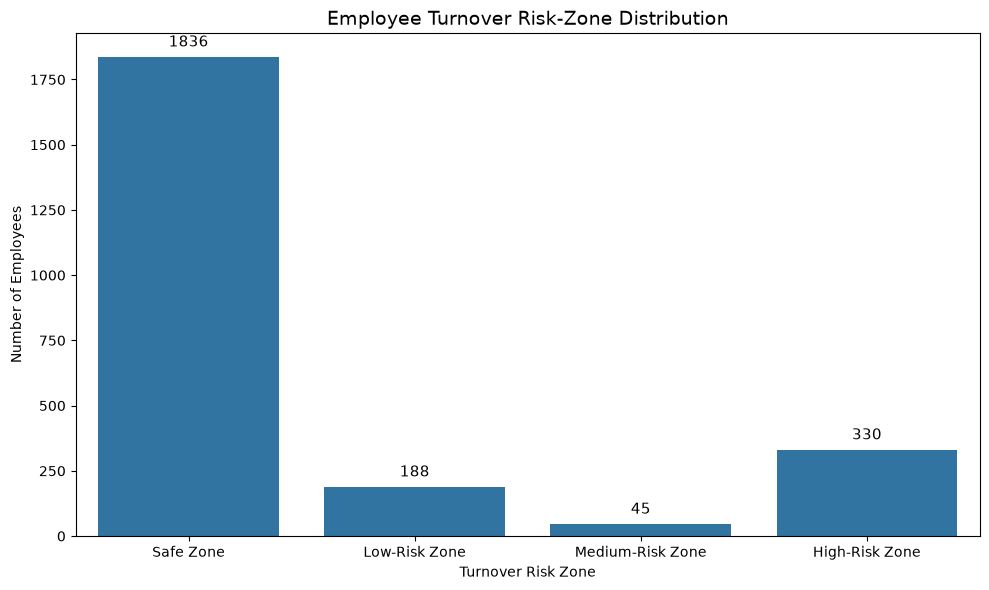

In [128]:
# Create the risk-zone bar chart
plt.figure(figsize=(10, 6))

risk_zone_chart = sns.barplot(
    data=risk_zone_summary,
    x="Risk Zone",
    y="Number of Employees"
)

# Add the number of employees above each bar
for bar in risk_zone_chart.patches:
    bar_height = bar.get_height()

    risk_zone_chart.annotate(
        f"{int(bar_height)}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar_height
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 5),
        textcoords="offset points"
    )

# Add the chart title and axis labels
plt.title(
    "Employee Turnover Risk-Zone Distribution",
    fontsize=14
)

plt.xlabel("Turnover Risk Zone")
plt.ylabel("Number of Employees")

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

## 13.7 Export the Employee Risk Results

The complete employee-risk dataset is exported to a CSV file.

The exported file contains the original employee characteristics, actual turnover outcome, model prediction, turnover probability, risk zone, and recommended retention strategy. This file can be used by HR for additional review and targeted retention planning.


In [129]:
# Define the output filename
risk_output_file = "employee_turnover_risk_results.csv"

# Export the employee-risk results to a CSV file
employee_risk_results.to_csv(
    risk_output_file,
    index=True
)

# Confirm that the file was created
print("Employee risk results saved successfully.")
print("Output file:", risk_output_file)
print("Number of exported employee records:", employee_risk_results.shape[0])

Employee risk results saved successfully.
Output file: employee_turnover_risk_results.csv
Number of exported employee records: 2399


### Risk-Zone Visualization and Export Interpretation

The risk-zone bar chart shows that most employees in the testing dataset are classified in the Safe Zone. A total of 1,836 employees have a predicted turnover probability below 20%.

The High-Risk Zone is the second-largest group, containing 330 employees. These employees should receive the highest priority for retention review and personalized intervention.

The Low-Risk Zone contains 188 employees, while the Medium-Risk Zone contains 45 employees. Although the Medium-Risk group is relatively small, these employees may benefit from targeted actions before their risk increases further.

The complete employee-risk dataset was successfully exported to `employee_turnover_risk_results.csv`. The file contains 2,399 employee records and includes the original employee characteristics, predicted turnover probability, assigned risk zone, and recommended retention strategy.


# 14. Final Project Conclusion

This project developed a machine-learning solution for predicting employee turnover at Portobello Tech.

The original dataset contained 14,999 employee records and 10 variables. No missing values were identified. However, 3,008 exact duplicate rows were found and removed, leaving 11,991 unique employee records for analysis.

Exploratory Data Analysis showed that employee satisfaction had the strongest numerical relationship with turnover, with a correlation of approximately -0.35. Employees with lower satisfaction levels were generally more likely to leave.

The project-count analysis revealed a nonlinear relationship between workload and turnover. Employees working on three or four projects were more likely to remain with the company, while employees assigned only two projects or six to seven projects showed considerably higher turnover. This suggests that both underutilization and excessive workload may contribute to employee departures.

K-means clustering identified three distinct groups among employees who left:

1. Highly dissatisfied employees with strong evaluation scores.
2. Highly satisfied and highly evaluated employees who still left.
3. Moderately dissatisfied employees with lower evaluation scores.

These clusters demonstrate that employee turnover is not caused by one single employee profile. Different groups may leave because of dissatisfaction, workload, career opportunities, compensation, performance challenges, or other factors not included in the dataset.

Three machine-learning models were trained and evaluated using leakage-safe five-fold cross-validation and an untouched testing dataset:

| Model               | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| ------------------- | -------: | --------: | -----: | -------: | ------: |
| Logistic Regression |   77.57% |    41.21% | 82.41% |   54.94% |  83.18% |
| Random Forest       |   97.12% |    91.86% | 90.70% |   91.28% |  97.35% |
| Gradient Boosting   |   95.96% |    85.08% | 91.71% |   88.27% |  97.71% |

Random Forest was selected as the best overall model. Although Gradient Boosting achieved slightly higher recall and ROC-AUC, Random Forest produced the highest accuracy, precision, and F1 score and generated substantially fewer false-positive alerts.

The Random Forest confusion matrix showed that it correctly identified 361 of the 398 employees who left. It produced only 37 false negatives and 32 false positives.

The selected model was used to assign the testing employees to four turnover-risk zones:

* Safe Zone: 1,836 employees
* Low-Risk Zone: 188 employees
* Medium-Risk Zone: 45 employees
* High-Risk Zone: 330 employees

A total of 375 employees were assigned to the Medium- or High-Risk zones. These employees should receive the highest priority for targeted retention actions.

Recommended retention actions include employee recognition, regular manager check-ins, workload reviews, stay interviews, career-development planning, compensation reviews, promotion discussions, and personalized intervention plans.

Overall, the project demonstrates that machine learning can help HR identify employees who may be at risk of leaving and support more targeted, proactive, and evidence-based retention decisions.


## 14.1 Limitations and Future Improvements

Although the models produced strong results, several limitations should be considered.

The dataset does not contain a unique employee identifier. Therefore, the 3,008 exact duplicate rows were treated as duplicate observations, although it is possible that some records represented different employees with identical characteristics.

The analysis identifies relationships and predictive patterns but does not prove that any individual factor directly causes employee turnover.

The dataset also does not include other potentially important factors, such as manager quality, employee engagement survey responses, commute distance, benefits, job level, external employment opportunities, or personal reasons for leaving.

The predicted turnover probabilities should be used to support HR decisions rather than automatically determine how an employee is treated. Employees should not be labeled or approached solely based on a model prediction.

Future improvements could include:

* Hyperparameter tuning for Random Forest and Gradient Boosting.
* Probability calibration to improve the interpretation of risk scores.
* Additional employee-engagement and management variables.
* Model fairness testing across employee groups.
* Monitoring model performance over time.
* Retraining the model when employee behavior or organizational conditions change.
* Using stay-interview outcomes to improve future predictions.

The model should therefore be treated as an employee-retention decision-support tool rather than a replacement for professional HR judgment.
